<img src="image_filename.png" width="">

## Company Background

Airbnb is a modern company operating in the hospitality industry through an innovative, platform-based business model. Instead of owning hotels, Airbnb collaborates with homeowners who list their properties for short-term rentals.

Homeowners can register and publish their property listings on the platform, making them available to travelers seeking accommodation. Users can browse these listings and make bookings directly through the Airbnb application.

Today, Airbnb operates globally, connecting millions of hosts and guests across various countries. The platform makes it easy for travelers to find accommodation based on their budget, preferred design, and the surrounding environment of the location they choose.

## Stakeholder Segment

**Primary Stakeholder: Revenue Management / Pricing Team (Airbnb Bangkok, Thailand)**  

This team focuses on optimizing pricing strategies to maximize booking performance across the platform.

**How this analysis supports them:**
- Identify high-performing price and room type segments  
- Provide data-driven pricing recommendations for hosts  
- Highlight top-performing neighbourhood combinations  
- Enable better in-app suggestions and targeted marketing campaigns

## Problem Statement

Airbnb aims to understand the key drivers of listing performance in Bangkok, specifically how **price positioning, neighbourhood context, and room type** influence demand. The goal is to identify why some listings underperform and how pricing strategy can be used to improve overall marketplace efficiency.

As a data analyst, the objective is to translate marketplace behavior into actionable pricing and supply recommendations that help underperforming listings move toward higher-demand segments. We aim to answer two key business questions:

- **Q1. Which price and room type segments should Airbnb prioritize to maximize overall demand?**
- **Q2. Which price, neighbourhood, and room type combinations deliver the most consistent bookings, and how can pricing guide hosts toward them?**

## Dataset

This analysis uses Airbnb listing data from Bangkok, Thailand. The dataset can be accessed [here](https://drive.google.com/drive/folders/1A_KBMRFTS5Mthpp46nulso679ML4ZwTF?usp=sharing).

| Column | Description |
|---|---|
| `id` | Unique listing identifier |
| `host_id` | Unique host identifier |
| `neighbourhood` | Bangkok district where the listing is located |
| `latitude` / `longitude` | Geographic coordinates |
| `room_type` | Entire home/apt, Private room, Hotel room, or Shared room |
| `price` | Nightly price in THB |
| `minimum_nights` | Minimum nights required per booking |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly review rate |
| `calculated_host_listings_count` | Number of listings the host owns |
| `availability_365` | Days available per year |
| `number_of_reviews_ltm` | Reviews in the last 12 months |

In [1]:
## Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy import stats
from itertools import combinations
import folium
import requests

warnings.filterwarnings('ignore')
from IPython.display import display, Markdown

# Show full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [135]:
# Load dataset
df = pd.read_csv('airbnb_bangkok_listings.csv')

display(df.head(3), df.tail(3))

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,0,27934.0,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.5,2,353,0
1,1,27979.0,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaN,NaN,2,358,0
2,2,28745.0,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaN,NaN,1,365,0


,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
15851,15851,7.904753e+17,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaN,NaN,14,365,0
15852,15852,7.904755e+17,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaN,NaN,14,365,0
15853,15853,7.904765e+17,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.752960,100.540820,Private room,1214,1,0,NaN,NaN,14,365,0


## Data Understanding

Before cleaning, we explore the dataset structure to identify any issues that need to be addressed.

In [68]:
# Dataset shape
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows: 15,854
Columns: 17


In [69]:
# Dataset column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      15854 non-null  int64  
 1   id                              15854 non-null  int64  
 2   name                            15846 non-null  object 
 3   host_id                         15854 non-null  int64  
 4   host_name                       15853 non-null  object 
 5   neighbourhood                   15854 non-null  object 
 6   latitude                        15854 non-null  float64
 7   longitude                       15854 non-null  float64
 8   room_type                       15854 non-null  object 
 9   price                           15854 non-null  int64  
 10  minimum_nights                  15854 non-null  int64  
 11  number_of_reviews               15854 non-null  int64  
 12  last_review                     

In [70]:
# Summary statistics (Numeric)
df.describe().round(2)

,Unnamed: 0,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,15854.00,1.585400e+04,1.585400e+04,15854.00,15854.00,15854.00,15854.00,15854.00,10064.00,15854.00,15854.00,15854.00
mean,7926.50,1.579397e+17,1.541058e+08,13.75,100.56,3217.70,15.29,16.65,0.81,13.89,244.38,3.48
std,4576.80,2.946015e+17,1.318726e+08,0.04,0.05,24972.12,50.82,40.61,1.09,30.27,125.84,8.92
min,0.00,2.793400e+04,5.892000e+04,13.53,100.33,0.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,3963.25,2.104509e+07,3.974431e+07,13.72,100.53,900.00,1.00,0.00,0.12,1.00,138.00,0.00
50%,7926.50,3.503734e+07,1.224556e+08,13.74,100.56,1429.00,1.00,2.00,0.44,4.00,309.00,0.00
75%,11889.75,5.256154e+07,2.390547e+08,13.76,100.59,2429.00,7.00,13.00,1.06,13.00,360.00,3.00
max,15853.00,7.908162e+17,4.926659e+08,13.95,100.92,1100000.00,1125.00,1224.00,19.13,228.00,365.00,325.00


In [71]:
# Summary statistics (Text)
df.describe(include='object')

,name,host_name,neighbourhood,room_type,last_review
count,15846,15853,15854,15854,10064
unique,14794,5312,50,4,1669
top,New! La Chada Night Market studio 2PPL near MRT,Curry,Vadhana,Entire home/apt,2022-12-11
freq,45,228,2153,8912,189


In [72]:
# Unique values per column
summary = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[c].nunique() for c in df],
    'Sample': [df[c].dropna().unique()[:5].tolist() for c in df.columns]
})
summary

,Column,Unique Values,Sample
0,Unnamed: 0,15854,"[0, 1, 2, 3, 4]"
1,id,15854,"[27934, 27979, 28745, 35780, 941865]"
2,name,14794,"[Nice room with superb city view, Easy going landlord,easy place, modern-style apartment in Bangkok, Spacious one bedroom at The Kris Condo Bldg. 3, Suite Room 3 at MetroPoint]"
3,host_id,6659,"[120437, 120541, 123784, 153730, 610315]"
4,host_name,5312,"[Nuttee, Emy, Familyroom, Sirilak, Kasem]"
5,neighbourhood,50,"[Ratchathewi, Bang Na, Bang Kapi, Din Daeng, Bang Kho laen]"
6,latitude,9606,"[13.75983, 13.66818, 13.75232, 13.78823, 13.76872]"
7,longitude,10224,"[100.54134, 100.61674, 100.62402, 100.57256, 100.63338]"
8,room_type,4,"[Entire home/apt, Private room, Hotel room, Shared room]"
9,price,3040,"[1905, 1316, 800, 1286, 1000]"


**Key observations**

In general, we can observe that:

1. Dataset has 15,854 rows and 17 columns; missing values mainly in `last_review` and `reviews_per_month` (~36%), indicating low/no activity listings.

2. `last_review` is in object format and should be converted to datetime for time-based analysis.

3. ID columns (`id`, `host_id`, `Unnamed: 0`) are not useful for analysis or modeling.

4. Location features (`latitude`, `longitude`, `neighbourhood`) are complete and useful for spatial insights.

5. `price` is numeric but likely skewed, requiring outlier handling or transformation.

6. Review metrics (`number_of_reviews`, etc.) indicate demand and listing performance.

7. `room_type`, `minimum_nights`, and `availability_365` reflect pricing and booking strategy.

## Data Cleaning

We identified initial data issues. Next, we will clean and handle them step by step before analysis.

#### Step 1 — Check for duplicates

Every listing should have a unique `id`. We check for full row duplicates and duplicate listing IDs.

In [73]:
# Full row duplicates
print("Duplicate rows:", df.duplicated().sum())

# Duplicate listing IDs
print("Duplicate listing IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate listing IDs: 0


From the results, no duplicate rows or duplicated `id` values were found, indicating the dataset is clean in this aspect.

#### Step 2 — Remove irrelevant columns

Some columns have no analytical value for our business questions and can be dropped:

- `Unnamed: 0`: Redundant index from data export  
- `name`: Too unstructured for meaningful aggregation  
- `host_name`: Not relevant to pricing or demand patterns  

In [74]:
# Drop columns not needed for analysis
df = df.drop(columns=['Unnamed: 0', 'name', 'host_name'])

print('Remaining columns:', df.shape[1])

Remaining columns: 14


In [75]:
columns_df = pd.DataFrame(df.columns, columns=['column_name'])
columns_df

,column_name
0,id
1,host_id
2,neighbourhood
3,latitude
4,longitude
5,room_type
6,price
7,minimum_nights
8,number_of_reviews
9,last_review


#### Step 3 — Handle missing values

Handle missing values to avoid errors and bias in analysis:

- Check missing values  
- Decide how to handle them  
- Apply appropriate treatment  

In [76]:
# Missing value summary
df_null = pd.DataFrame({
    'Null Count': df.isna().sum(),
    'Null Percentage': (df.isna().sum() / len(df) * 100).round(2)
})

df_null

,Null Count,Null Percentage
id,0,0.00
host_id,0,0.00
neighbourhood,0,0.00
latitude,0,0.00
longitude,0,0.00
room_type,0,0.00
price,0,0.00
minimum_nights,0,0.00
number_of_reviews,0,0.00
last_review,5790,36.52


<h3 style='text-align:center;'>Column: price</h3>

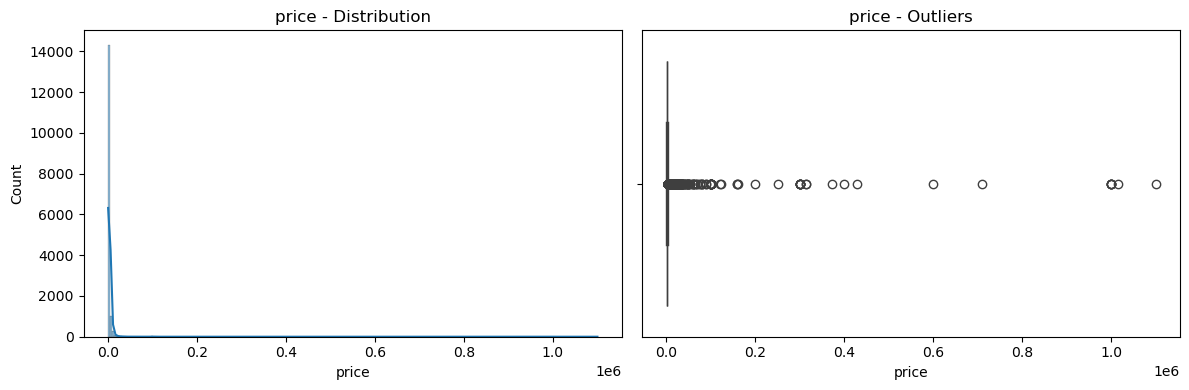

<h3 style='text-align:center;'>Column: minimum_nights</h3>

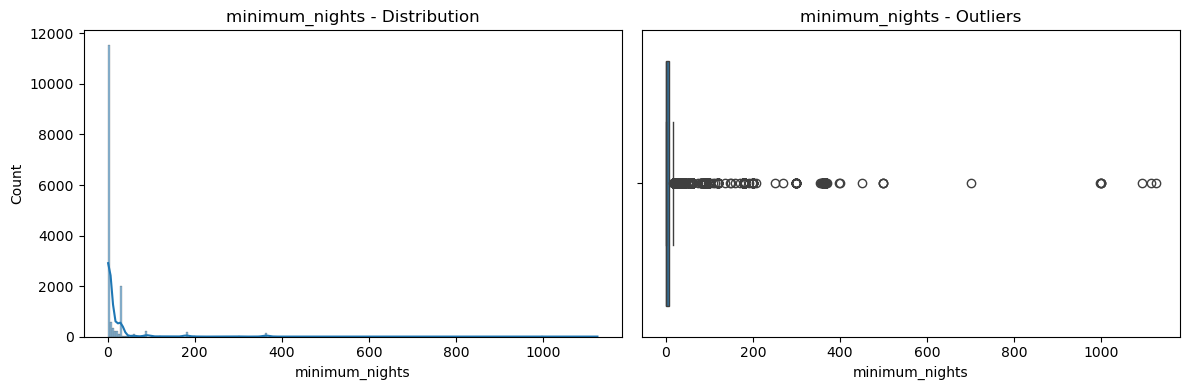

<h3 style='text-align:center;'>Column: number_of_reviews</h3>

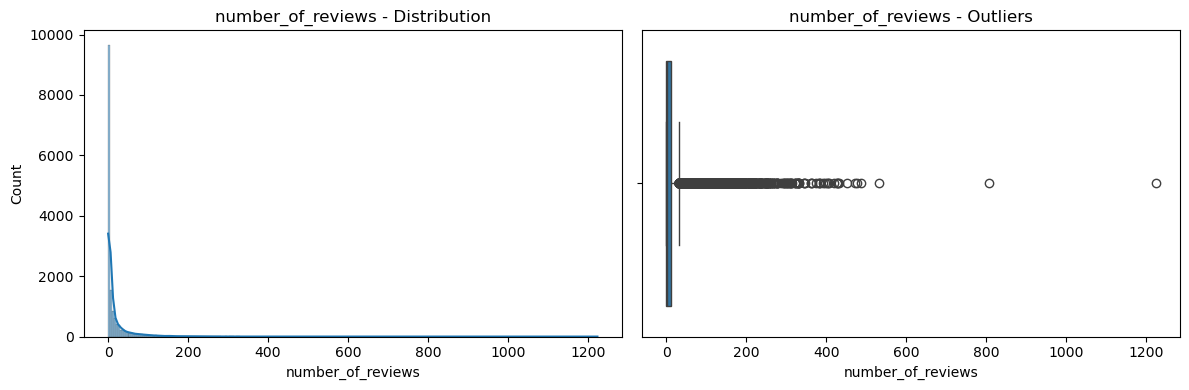

<h3 style='text-align:center;'>Column: reviews_per_month</h3>

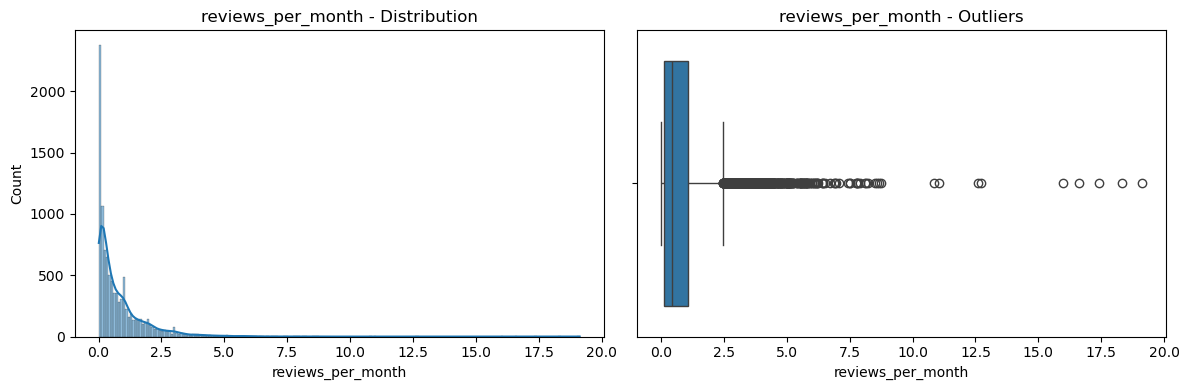

<h3 style='text-align:center;'>Column: calculated_host_listings_count</h3>

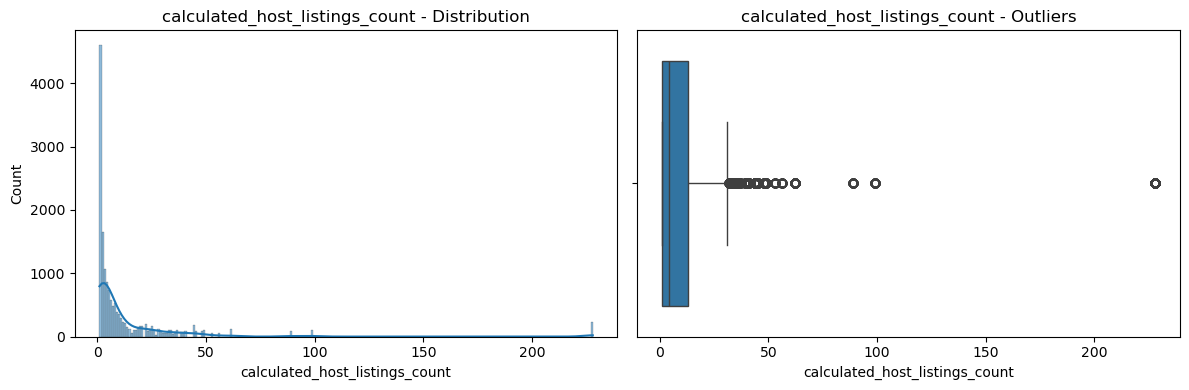

<h3 style='text-align:center;'>Column: availability_365</h3>

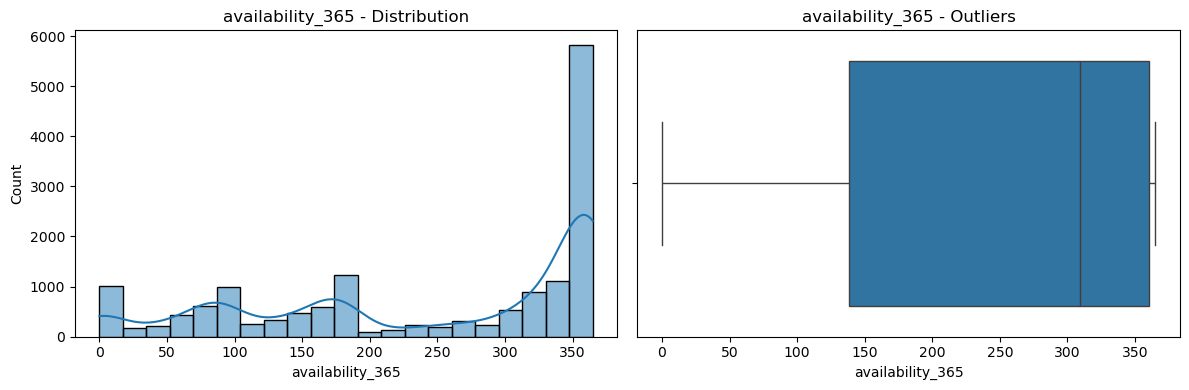

<h3 style='text-align:center;'>Column: number_of_reviews_ltm</h3>

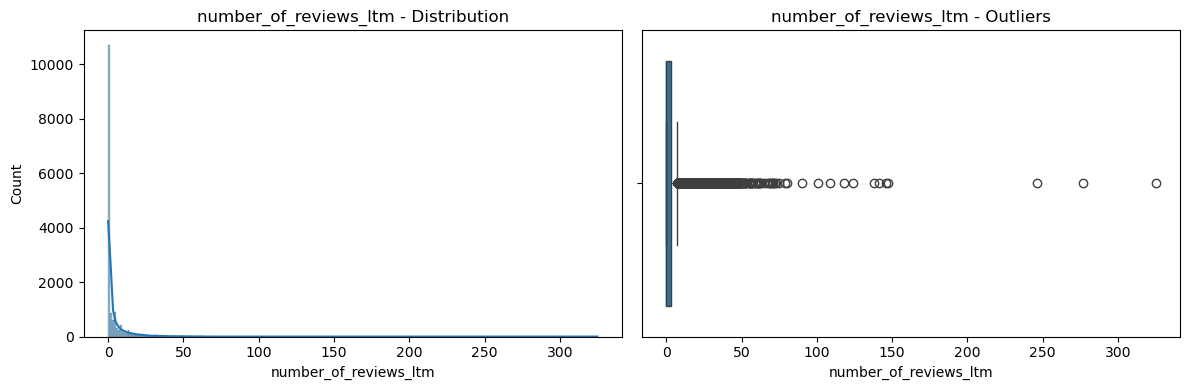

In [77]:
# Select numeric columns (exclude IDs)
cols_to_plot = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'number_of_reviews_ltm'
]

# Check distribution
for col in cols_to_plot:
    display(Markdown(f"<h3 style='text-align:center;'>Column: {col}</h3>"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram (distribution)
    sns.histplot(df[col], ax=axes[0], kde=True)
    axes[0].set_title(f'{col} - Distribution')

    # Boxplot (outliers)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Outliers')

    plt.tight_layout()
    plt.show()

**Summary**:

- **Price & Minimum Nights:** Highly skewed. Most listings are low-priced, but extreme outliers reach up to **1e6** THB. Minimum nights are usually **1–7 days**, with some extreme cases over **1,000 days**, likely long-term rentals or data issues.
- **Review Activity:** Most listings have **0–50 reviews**, while a small number have hundreds. Reviews per month are mostly **near zero**, showing many listings have little or no activity.
- **Host & Availability:** Most hosts manage **1–5 listings**, but a few manage **200+**. Availability is clearly split into two groups: **0 days** (inactive/unavailable) and **365 days** (fully available).

**Takeaway**: The dataset is heavily skewed with many outliers, so price and minimum nights should be capped, skewed features should be log-transformed, and availability must be handled carefully due to its bimodal pattern (inactive vs fully available listings).

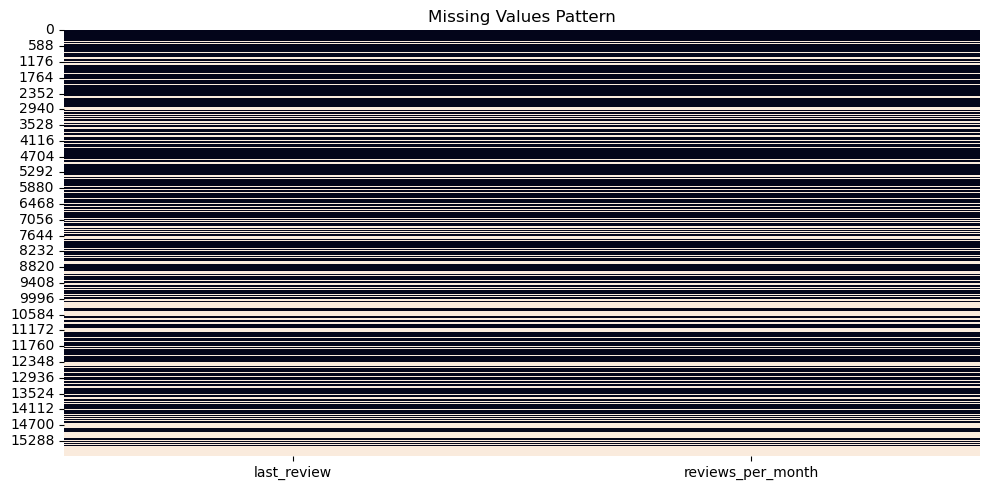

In [78]:
# Visualize missing values
plt.figure(figsize=(10, 5))

sns.heatmap(df[['last_review', 'reviews_per_month']].isna(), cbar=False)

plt.title('Missing Values Pattern')
plt.tight_layout()
plt.show()

**Why are these values missing?**

`last_review` and `reviews_per_month` are missing because those listings have no review activity recorded.

- No review exists → `last_review` remains `NaT` since there is no date to store  
- No activity detected → `reviews_per_month` is set to `0` because there are no reviews to calculate frequency from  

This is not a data issue. It simply reflects listings with no guest feedback history, which usually means they are new, inactive, or never received bookings.

In [79]:
# Transform last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

We transform the `last_review` data type to enable time-based analysis and ensure a correct date format.

In [80]:
# Fill reviews_per_month with 0 → no reviews means 0 monthly activity
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Keep last_review as NaT → indicates no review activity
df['last_review'] = df['last_review']

In [81]:
# Verify handled missing values
df[['last_review', 'reviews_per_month']].isnull().sum()

last_review          5790
reviews_per_month       0
dtype: int64

Note:
`last_review` still has missing values because listings with no reviews have no review date. This is expected.

In [82]:
# Add a flag column: 1 = has reviews, 0 = no reviews
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

# Preview
df[['number_of_reviews', 'last_review', 'reviews_per_month', 'has_reviews']].head()

,number_of_reviews,last_review,reviews_per_month,has_reviews
0,65,2020-01-06,0.50,1
1,0,NaT,0.00,0
2,0,NaT,0.00,0
3,2,2022-04-01,0.03,1
4,0,NaT,0.00,0


Note:
`has_reviews` helps distinguish listings with and without review activity.

#### Step 4 — Remove anomalies

We identified three columns with suspicious values during data understanding.

**Price**

In [83]:
# How many listings have price = 0?
print('Listings with price = 0 :', df[df['price'] == 0].shape[0])

Listings with price = 0 : 1


Note:
There is 1 listing with price = 0, which is likely a data error or special case and should be removed.

In [84]:
# What does the high end look like?
df[df['price'] > 10000][['neighbourhood', 'room_type', 'price']].sort_values('price', ascending=False).head(10)

,neighbourhood,room_type,price
12868,Vadhana,Entire home/apt,1100000
12300,Vadhana,Entire home/apt,1014758
1779,Huai Khwang,Entire home/apt,1000000
6289,Khlong Toei,Entire home/apt,1000000
9345,Khlong Toei,Entire home/apt,1000000
4620,Huai Khwang,Entire home/apt,1000000
1239,Huai Khwang,Entire home/apt,1000000
15200,Khlong San,Entire home/apt,710760
4373,Bang Phlat,Private room,600700
11885,Bang Kapi,Private room,429443


Note:
Extreme high prices indicate outliers that may affect pricing analysis.

In [85]:
# Remove invalid prices
df = df[df['price'] > 0]

# Remove extreme outliers (99th percentile cap)
price_cap = df['price'].quantile(0.99)
df = df[df['price'] <= price_cap]

print(f'Price cap (99th percentile): {price_cap:,.0f} THB')
print(f'Rows remaining: {df.shape[0]:,}')

Price cap (99th percentile): 18,000 THB
Rows remaining: 15,701


Note:
Outliers above 18,000 THB are removed, keeping the data more realistic for pricing analysis.

**Minimum nights**

In [86]:
# Check the extreme end of minimum_nights
df[df['minimum_nights'] > 365][['neighbourhood', 'room_type', 'minimum_nights']].sort_values('minimum_nights').head(10)

,neighbourhood,room_type,minimum_nights
324,Khlong Toei,Entire home/apt,370
11416,Dusit,Private room,400
8608,Lat Phrao,Entire home/apt,450
1833,Suanluang,Entire home/apt,500
3694,Vadhana,Entire home/apt,500
1592,Chatu Chak,Entire home/apt,700
10644,Vadhana,Private room,999
11243,Suanluang,Private room,999
10153,Sathon,Entire home/apt,1000
11524,Bang Sue,Entire home/apt,1095


In [87]:
print('Maximum minimum_nights:', df['minimum_nights'].max())

Maximum minimum_nights: 1125


Note:
Some listings have extremely high minimum nights (up to 1125), indicating long-term rental strategies or outliers that may affect demand analysis. These are outside the scope of this analysis → **dropped**.

In [88]:
# Keep only short-term rental listings (minimum_nights <= 365)
df = df[df['minimum_nights'] <= 365]
print(f'Rows remaining : {df.shape[0]:,}')

Rows remaining : 15,689


**Availability**

In [89]:
# How many listings have 0 days available per year?
print('Listings with availability = 0 :', df[df['availability_365'] == 0].shape[0])

Listings with availability = 0 : 850


In [90]:
df[df['availability_365'] == 0][['neighbourhood', 'room_type', 'price']].head()

,neighbourhood,room_type,price
51,Bang Rak,Entire home/apt,2701
104,Chatu Chak,Entire home/apt,1004
141,Phaya Thai,Private room,399
152,Khlong Toei,Entire home/apt,1489
205,Chatu Chak,Entire home/apt,866


Note:
850 listings have zero availability (fully booked or inactive) and don’t reflect current demand → **drop**.

In [91]:
# Keep only bookable listings
df = df[df['availability_365'] > 0]
print(f'Rows remaining : {df.shape[0]:,}')

Rows remaining : 14,839


#### Cleaning summary

Quick check on the dataset after all cleaning steps.

In [92]:
print(f'Final dataset : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print()

Final dataset : 14,839 rows  x  15 columns



In [93]:
df[['price', 'minimum_nights', 'availability_365']].describe().round(0)

,price,minimum_nights,availability_365
count,14839.0,14839.0,14839.0
mean,2059.0,15.0,258.0
std,2112.0,45.0,115.0
min,278.0,1.0,1.0
25%,900.0,1.0,161.0
50%,1422.0,1.0,321.0
75%,2366.0,7.0,361.0
max,18000.0,365.0,365.0


**Summary**
- Price: Heavily right-skewed. Mean is 2,059 and median is 1,422, with high variance (std 2,112) and values up to 18,000.
- Minimum Nights: Mostly short-term stays. Median is 1 night, with extreme outliers up to 365 nights.
- Availability (365 Days): Generally high. Median is 321 days, meaning most listings are available most of the year.

## Exploratory Data Analysis

We now explore the data to answer our two business questions:

- **Q1.** What pricing strategies maximize demand by neighbourhood and room type?
- **Q2.** Which combination of price, neighbourhood, and room type performs best?

We start with individual variables, then look at relationships between them.

#### Price distribution

Understanding the overall price landscape before breaking it down by location and room type.

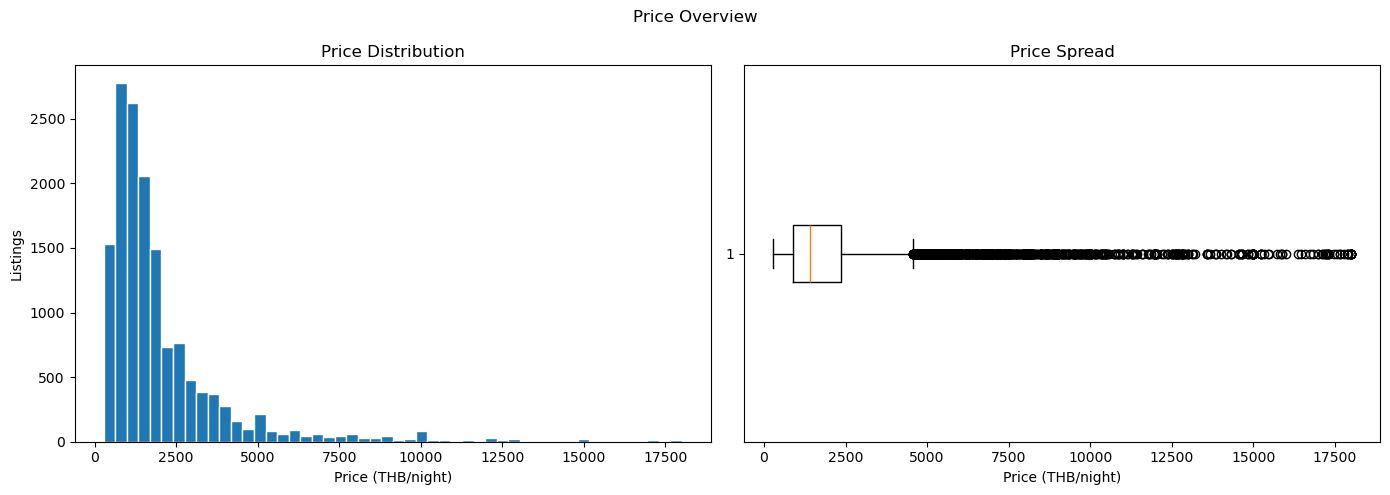

In [94]:
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax[0].hist(df['price'], bins=50, edgecolor='white')
ax[0].set_title('Price Distribution')
ax[0].set_xlabel('Price (THB/night)')
ax[0].set_ylabel('Listings')

# Spread
ax[1].boxplot(df['price'], vert=False)
ax[1].set_title('Price Spread')
ax[1].set_xlabel('Price (THB/night)')

plt.suptitle('Price Overview')
plt.tight_layout()
plt.show()

In [95]:
# Key stats
price_stats = df['price'].describe().round(0).to_frame()
price_stats

,price
count,14839.0
mean,2059.0
std,2112.0
min,278.0
25%,900.0
50%,1422.0
75%,2366.0
max,18000.0


**Findings (Price)**:
- Prices are right-skewed; the mean is 2,059 THB, which is higher than the median (1,422 THB).
- Most listings fall between 900–2,366 THB (25%–75% range)
- Minimum is 278 THB, while maximum reaches 18,000 THB
- Overall, a small number of high-end listings pull the average up

#### Price by room type

How does price differ between room categories?

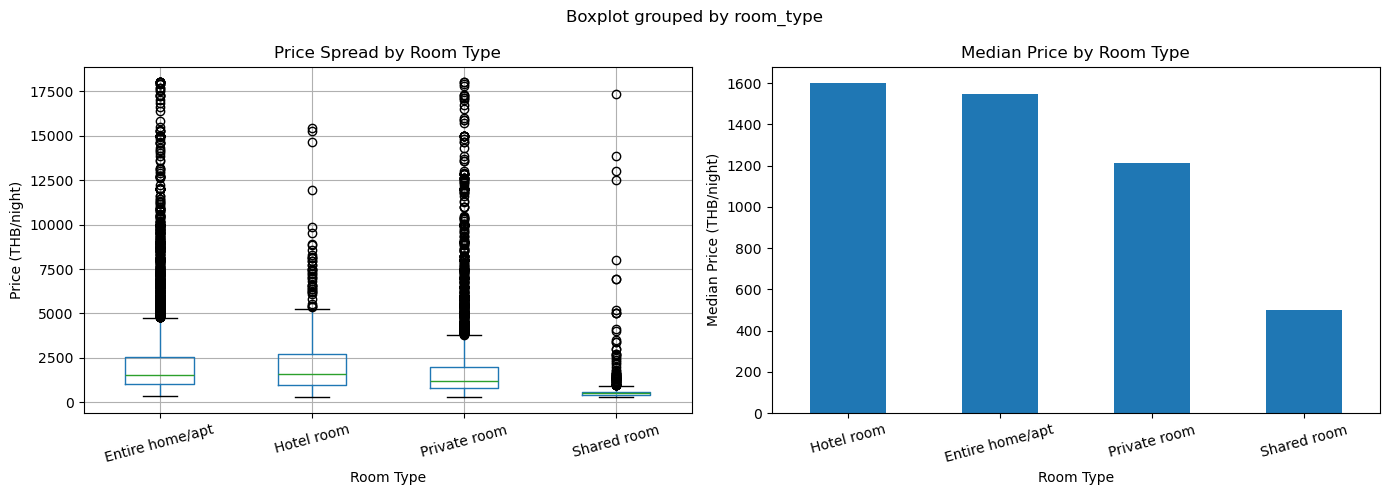

In [96]:
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Price spread
df.boxplot(column='price', by='room_type', ax=ax[0])
ax[0].set_title('Price Spread by Room Type')
ax[0].set_xlabel('Room Type')
ax[0].set_ylabel('Price (THB/night)')
ax[0].tick_params(axis='x', rotation=15)

# Median price
df.groupby('room_type')['price'].median().sort_values(ascending=False).plot(kind='bar', ax=ax[1])
ax[1].set_title('Median Price by Room Type')
ax[1].set_xlabel('Room Type')
ax[1].set_ylabel('Median Price (THB/night)')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [97]:
# Supply distribution (%)
supply = df['room_type'].value_counts(normalize=True) * 100

# Median price per room type
median = df.groupby('room_type')['price'].median()

# Combine into one clean table
summary = pd.concat([supply, median], axis=1)
summary.columns = ['Supply (%)', 'Median Price (THB)']
summary = summary.sort_values('Supply (%)', ascending=False)

print(summary.round(2))

                 Supply (%)  Median Price (THB)
room_type                                      
Entire home/apt       56.05              1546.0
Private room          36.75              1212.0
Hotel room             3.79              1600.0
Shared room            3.40               500.0


In [98]:
# Stats table
room_type_stats = df.groupby('room_type')['price'].describe().round(0).reset_index()
room_type_stats

,room_type,count,mean,std,min,25%,50%,75%,max
0,Entire home/apt,8318.0,2212.0,2096.0,332.0,1030.0,1546.0,2527.0,18000.0
1,Hotel room,563.0,2249.0,2041.0,318.0,1000.0,1600.0,2716.0,15442.0
2,Private room,5453.0,1922.0,2149.0,278.0,800.0,1212.0,2000.0,18000.0
3,Shared room,505.0,820.0,1457.0,280.0,390.0,500.0,600.0,17316.0


**Findings:**
- Entire home/apt: highest variability and upper prices (median ~1,546 THB, max 18,000).
- Hotel room: high pricing, median ~1,600 THB, limited listings.
- Private room: mid-range, median ~1,212 THB.
- Shared room: cheapest option, median ~500 THB.
- Entire home/apt has the widest price spread, showing the most flexible pricing.

#### Price by neighbourhood

Which areas command premium prices, and which are budget-friendly?

In [99]:
# Remove irrelevant neighbourhood
df = df[df['neighbourhood'] != 'Nong Chok']

Note:
Nong Chok should be removed as it is located on the far edge of Bangkok. Its low representation but high median values can distort neighbourhood and pricing analysis, affecting the overall results.

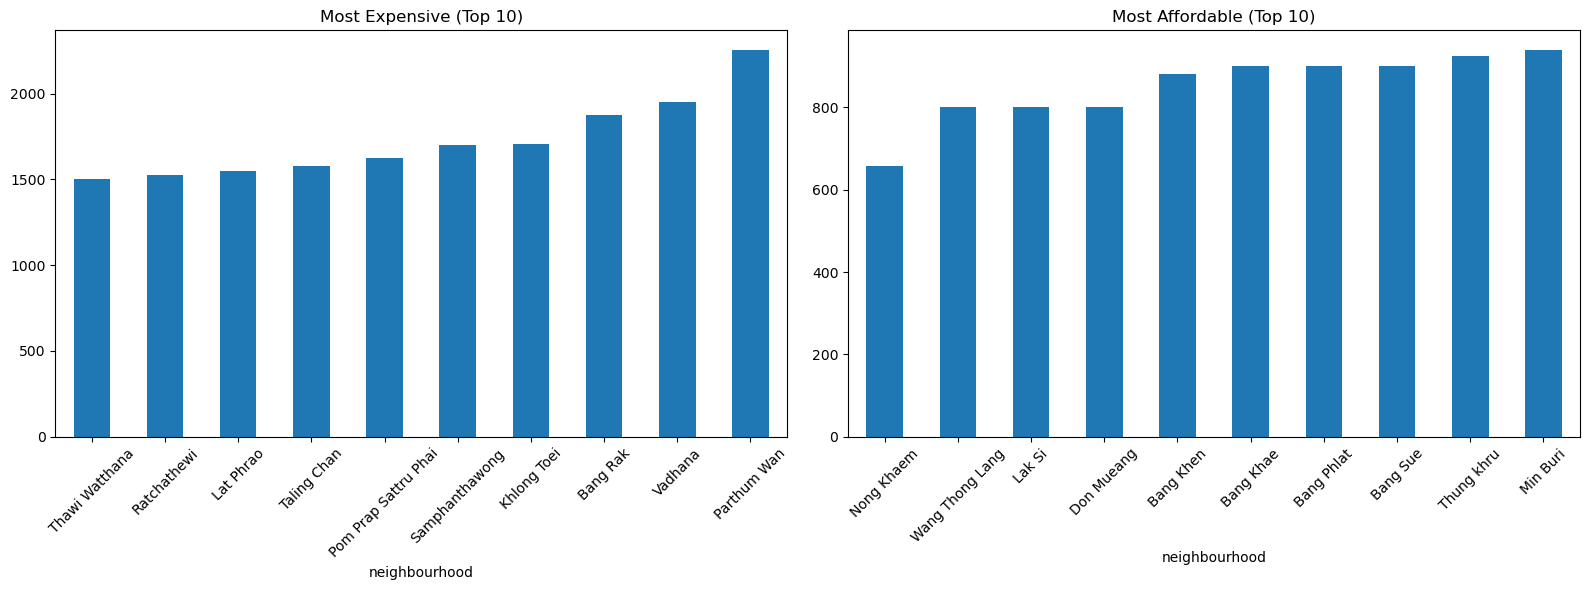

In [100]:
# Median price per neighbourhood, sorted highest to lowest
neighbourhood_price = df.groupby('neighbourhood')['price'].median().sort_values()

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 most expensive
neighbourhood_price.tail(10).plot(kind='bar', ax=ax[0])
ax[0].set_title('Most Expensive (Top 10)')
ax[0].tick_params(axis='x', rotation=45)

# Top 10 most affordable
neighbourhood_price.head(10).plot(kind='bar', ax=ax[1])
ax[1].set_title('Most Affordable (Top 10)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [101]:
# Neighbourhood price table
df_neighbourhood = neighbourhood_price.reset_index()
df_neighbourhood.columns = ['neighbourhood', 'median_price (THB)']

display(df_neighbourhood.head())
display(df_neighbourhood.tail())

,neighbourhood,median_price (THB)
0,Nong Khaem,658.0
1,Wang Thong Lang,800.0
2,Lak Si,800.0
3,Don Mueang,800.0
4,Bang Khen,880.0


,neighbourhood,median_price (THB)
44,Samphanthawong,1700.0
45,Khlong Toei,1707.0
46,Bang Rak,1874.0
47,Vadhana,1950.0
48,Parthum Wan,2257.0


**Findings**:
- Highest-priced neighbourhoods (Pathum Wan, Vadhana, Bang Rak) are centrally located near major transport lines and business districts.
- Lowest-priced areas (Nong Khaem, Don Mueang, Lak Si) are on the outskirts of Bangkok.
- Median prices range from 658 THB to 2,257 THB, showing a significant location-driven gap (~3–4x).
- Location is a key driver of Airbnb pricing.

#### Demand analysis

Since actual booking data is not available, we use `number_of_reviews`, `reviews_per_month`, and `last_review` as demand proxies. Listings with more reviews and recent review activity are assumed to have higher booking demand.

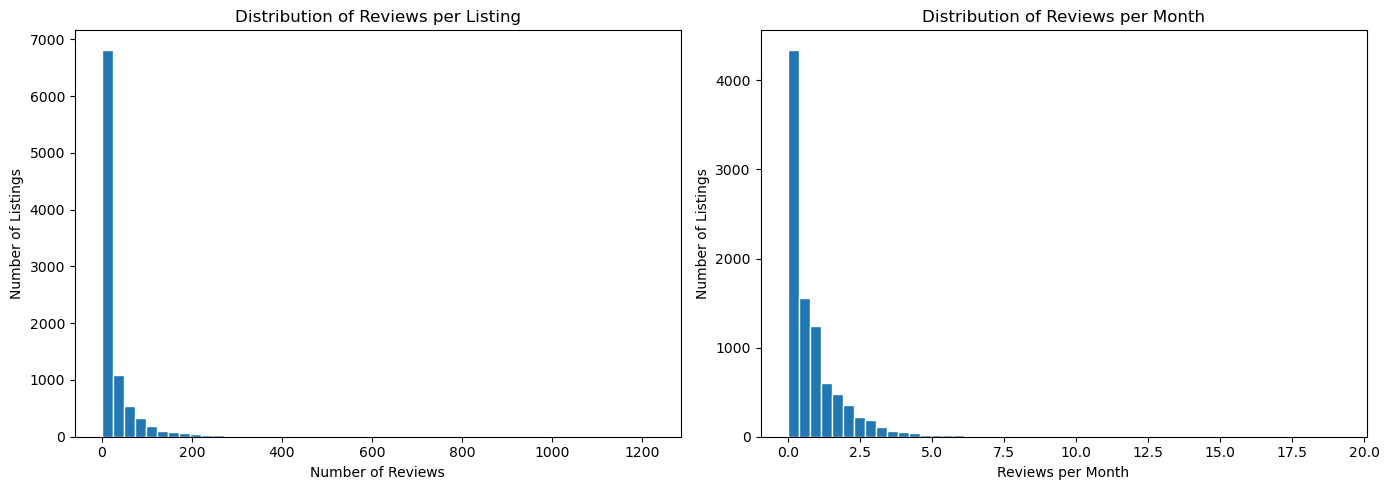

In [102]:
# Review volume & intensity distribution
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Review Count Distribution
ax[0].hist(df.loc[df['number_of_reviews'] > 0, 'number_of_reviews'],
           bins=50, edgecolor='white')
ax[0].set_title('Distribution of Reviews per Listing')
ax[0].set_xlabel('Number of Reviews')
ax[0].set_ylabel('Number of Listings')

# Reviews Per Month Distribution
ax[1].hist(df.loc[df['reviews_per_month'] > 0, 'reviews_per_month'],
           bins=50, edgecolor='white')
ax[1].set_title('Distribution of Reviews per Month')
ax[1].set_xlabel('Reviews per Month')
ax[1].set_ylabel('Number of Listings')

plt.tight_layout()
plt.show()

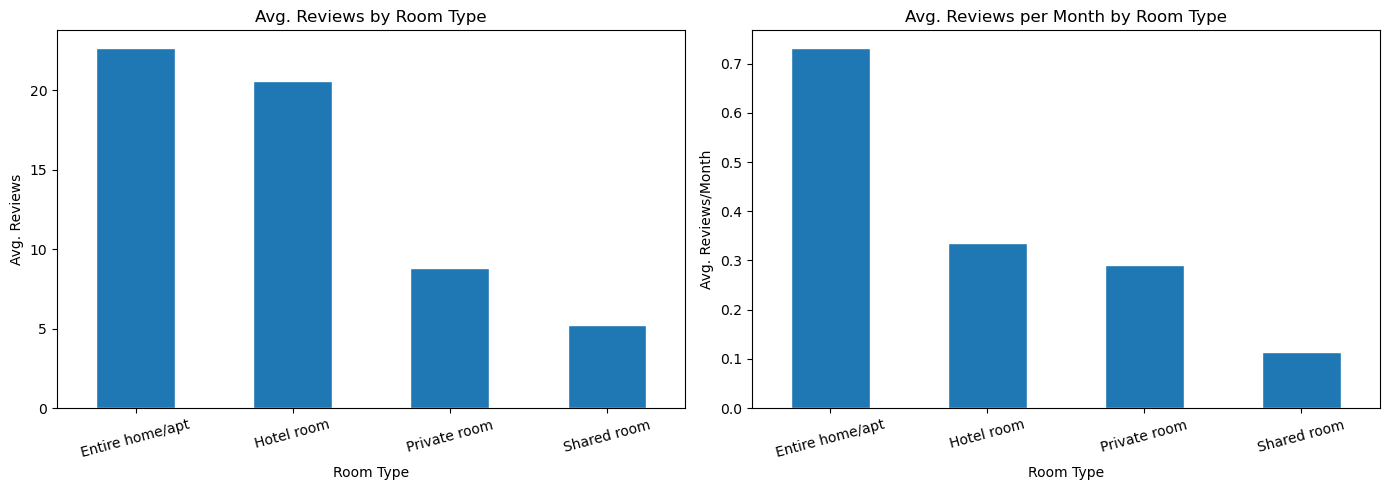

In [103]:
# Demand by room type
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Average Reviews by Room Type
df.groupby('room_type')['number_of_reviews'].mean().sort_values(ascending=False) \
    .plot(kind='bar', ax=ax[0], edgecolor='white')
ax[0].set_title('Avg. Reviews by Room Type')
ax[0].set_xlabel('Room Type')
ax[0].set_ylabel('Avg. Reviews')
ax[0].tick_params(axis='x', rotation=15)

# Average Reviews per Month by Room Type
df.groupby('room_type')['reviews_per_month'].mean().sort_values(ascending=False) \
    .plot(kind='bar', ax=ax[1], edgecolor='white')
ax[1].set_title('Avg. Reviews per Month by Room Type')
ax[1].set_xlabel('Room Type')
ax[1].set_ylabel('Avg. Reviews/Month')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

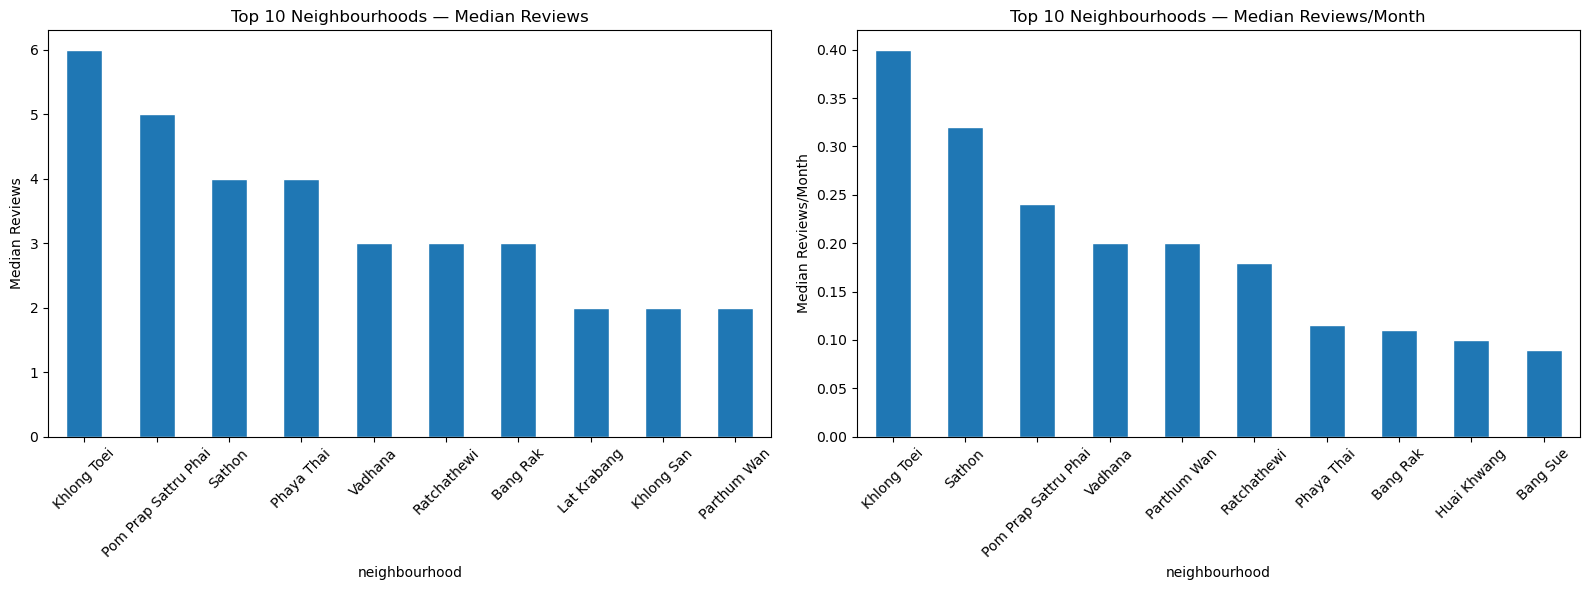

In [104]:
# Demand by neighbourhood
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Median Reviews by Neighbourhood (Top 10)
df.groupby('neighbourhood')['number_of_reviews'].median().sort_values(ascending=False).head(10) \
    .plot(kind='bar', ax=ax[0], edgecolor='white')
ax[0].set_title('Top 10 Neighbourhoods — Median Reviews')
ax[0].set_ylabel('Median Reviews')
ax[0].tick_params(axis='x', rotation=45)

# Median Reviews per Month by Neighbourhood (Top 10)
df.groupby('neighbourhood')['reviews_per_month'].median().sort_values(ascending=False).head(10) \
    .plot(kind='bar', ax=ax[1], edgecolor='white')
ax[1].set_title('Top 10 Neighbourhoods — Median Reviews/Month')
ax[1].set_ylabel('Median Reviews/Month')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

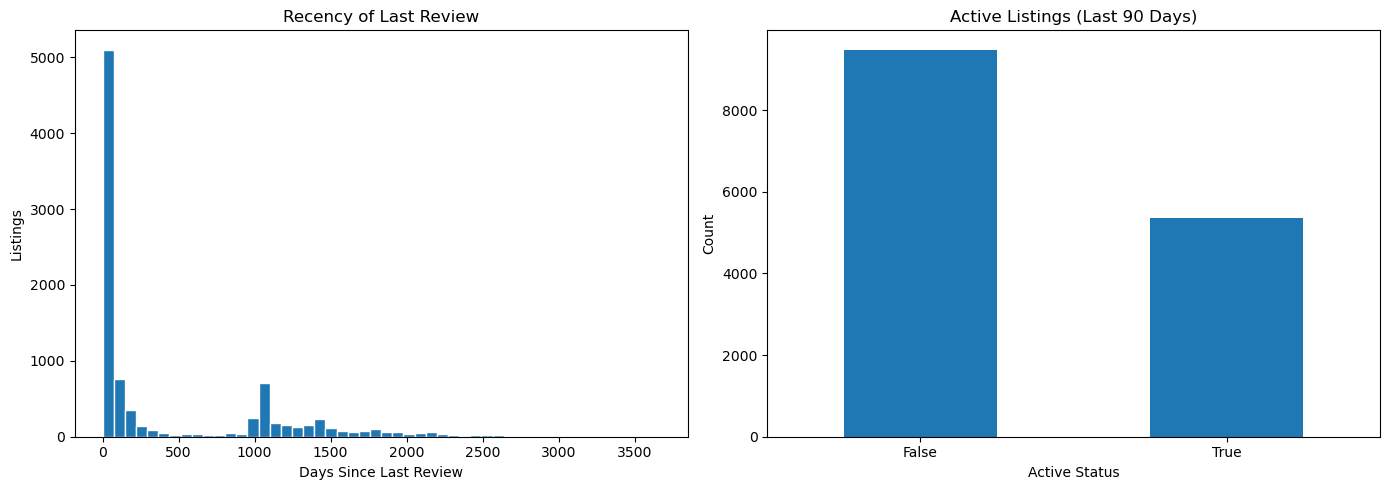

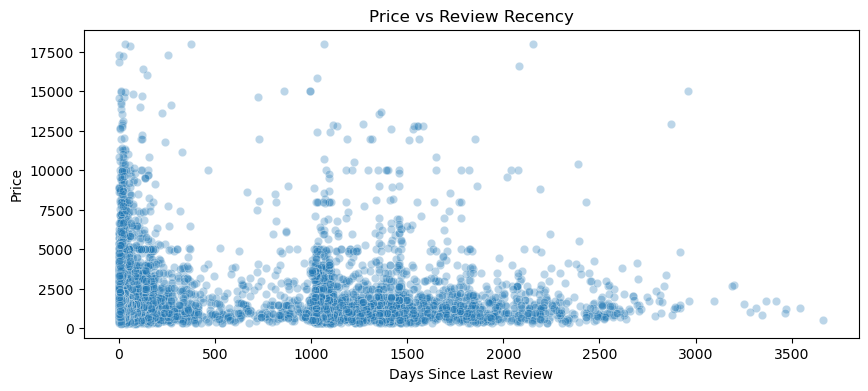

In [105]:
# Last review (recency / activity signal)
# Convert to datetime + create recency feature
df['last_review'] = pd.to_datetime(df['last_review'])
df['days_since_last_review'] = (df['last_review'].max() - df['last_review']).dt.days
df['active_90d'] = df['days_since_last_review'] <= 90

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Recency Distribution
ax[0].hist(df['days_since_last_review'].dropna(), bins=50, edgecolor='white')
ax[0].set_title('Recency of Last Review')
ax[0].set_xlabel('Days Since Last Review')
ax[0].set_ylabel('Listings')

# Active vs Inactive (90 Days)
df['active_90d'].value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title('Active Listings (Last 90 Days)')
ax[1].set_xlabel('Active Status')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Price vs Recency
plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df,
    x='days_since_last_review',
    y='price',
    alpha=0.3
)

plt.title('Price vs Review Recency')
plt.xlabel('Days Since Last Review')
plt.ylabel('Price')
plt.show()

**Findings**:
- ~36.5% of listings have no reviews, showing a large inactive demand segment.
- Demand is highly skewed, a small group of listings drives most activity.
- ~10,000 listings are inactive (no recent reviews), while ~5,000–6,000 show active demand.
- Entire homes/apartments lead demand across both total and monthly reviews.
- Demand clusters in Khlong Toei, Sathon, and nearby central areas.
- Lower-to-mid prices (<2,500–5,000) attract most demand; luxury listings have weaker demand.

**Conclusion**:
High-demand listings are entire homes in central areas, priced in the mid-range, with consistent review activity.

#### Price vs demand

This is the core relationship for answering **Q1**: which segments drive the most demand?

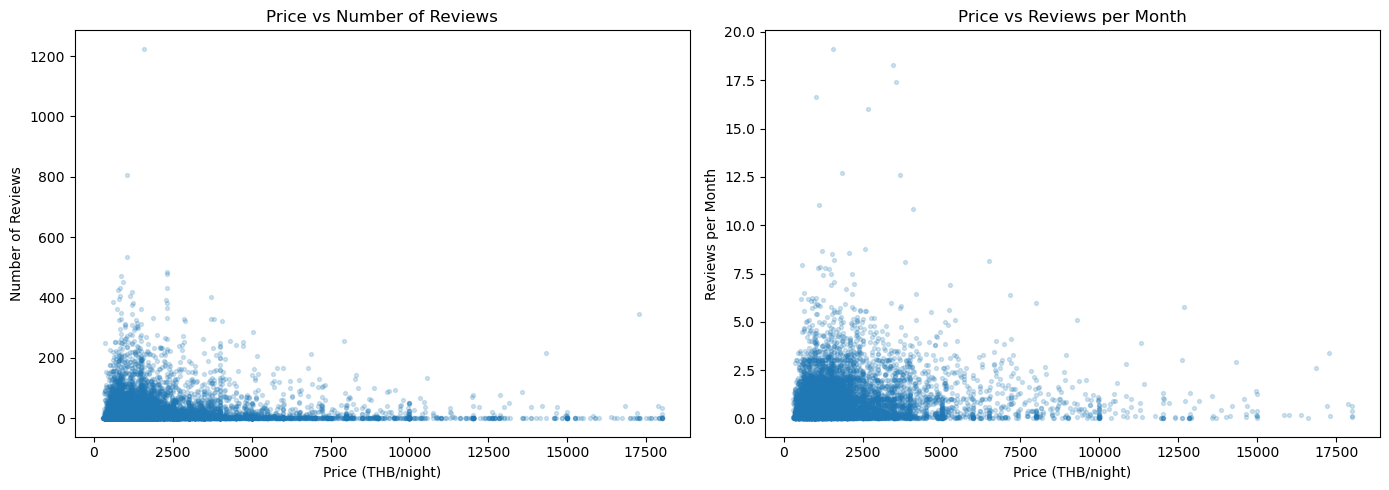

In [106]:
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Price vs Number of Reviews
ax[0].scatter(df['price'], df['number_of_reviews'], alpha=0.2, s=8)
ax[0].set_title('Price vs Number of Reviews')
ax[0].set_xlabel('Price (THB/night)')
ax[0].set_ylabel('Number of Reviews')

# Price vs Reviews per Month (Active Listings)
active = df[df['reviews_per_month'] > 0]

ax[1].scatter(active['price'], active['reviews_per_month'], alpha=0.2, s=8)
ax[1].set_title('Price vs Reviews per Month')
ax[1].set_xlabel('Price (THB/night)')
ax[1].set_ylabel('Reviews per Month')

plt.tight_layout()
plt.show()

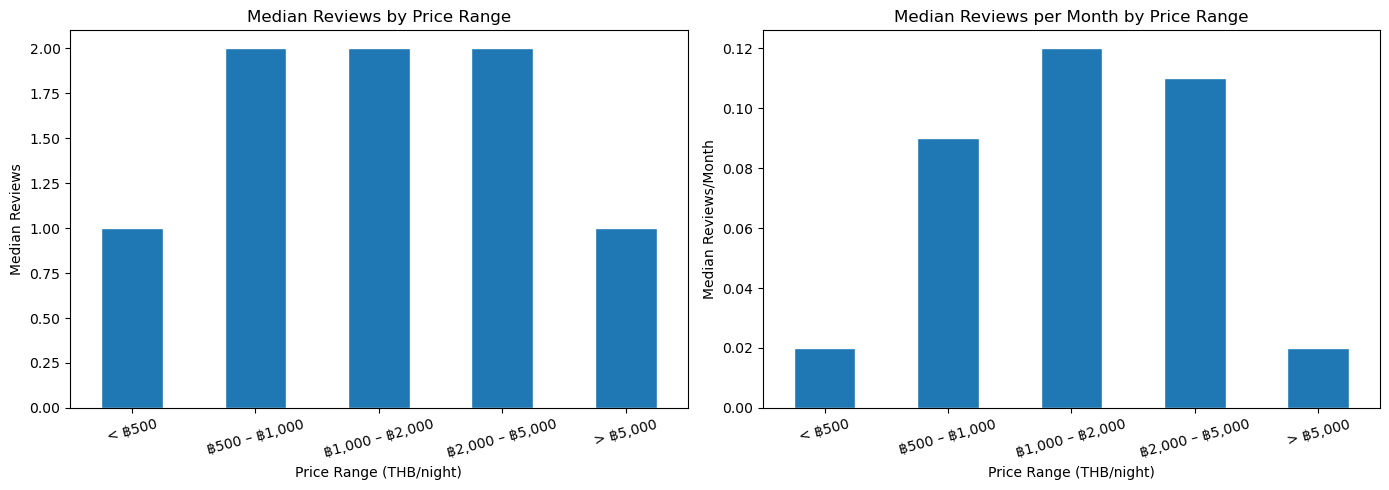

In [107]:
# Group price into buckets to compare demand clearly
df['price_bucket'] = pd.cut(
    df['price'],
    bins=[0, 500, 1000, 2000, 5000, df['price'].max()],
    labels=['< ฿500', '฿500 – ฿1,000', '฿1,000 – ฿2,000', '฿2,000 – ฿5,000', '> ฿5,000']
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Median Reviews by Price Bucket
df.groupby('price_bucket', observed=True)['number_of_reviews'].median() \
    .plot(kind='bar', ax=ax[0], edgecolor='white')
ax[0].set_title('Median Reviews by Price Range')
ax[0].set_xlabel('Price Range (THB/night)')
ax[0].set_ylabel('Median Reviews')
ax[0].tick_params(axis='x', rotation=15)

# Median Reviews per Month by Price Bucket
df.groupby('price_bucket', observed=True)['reviews_per_month'].median() \
    .plot(kind='bar', ax=ax[1], edgecolor='white')
ax[1].set_title('Median Reviews per Month by Price Range')
ax[1].set_xlabel('Price Range (THB/night)')
ax[1].set_ylabel('Median Reviews/Month')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

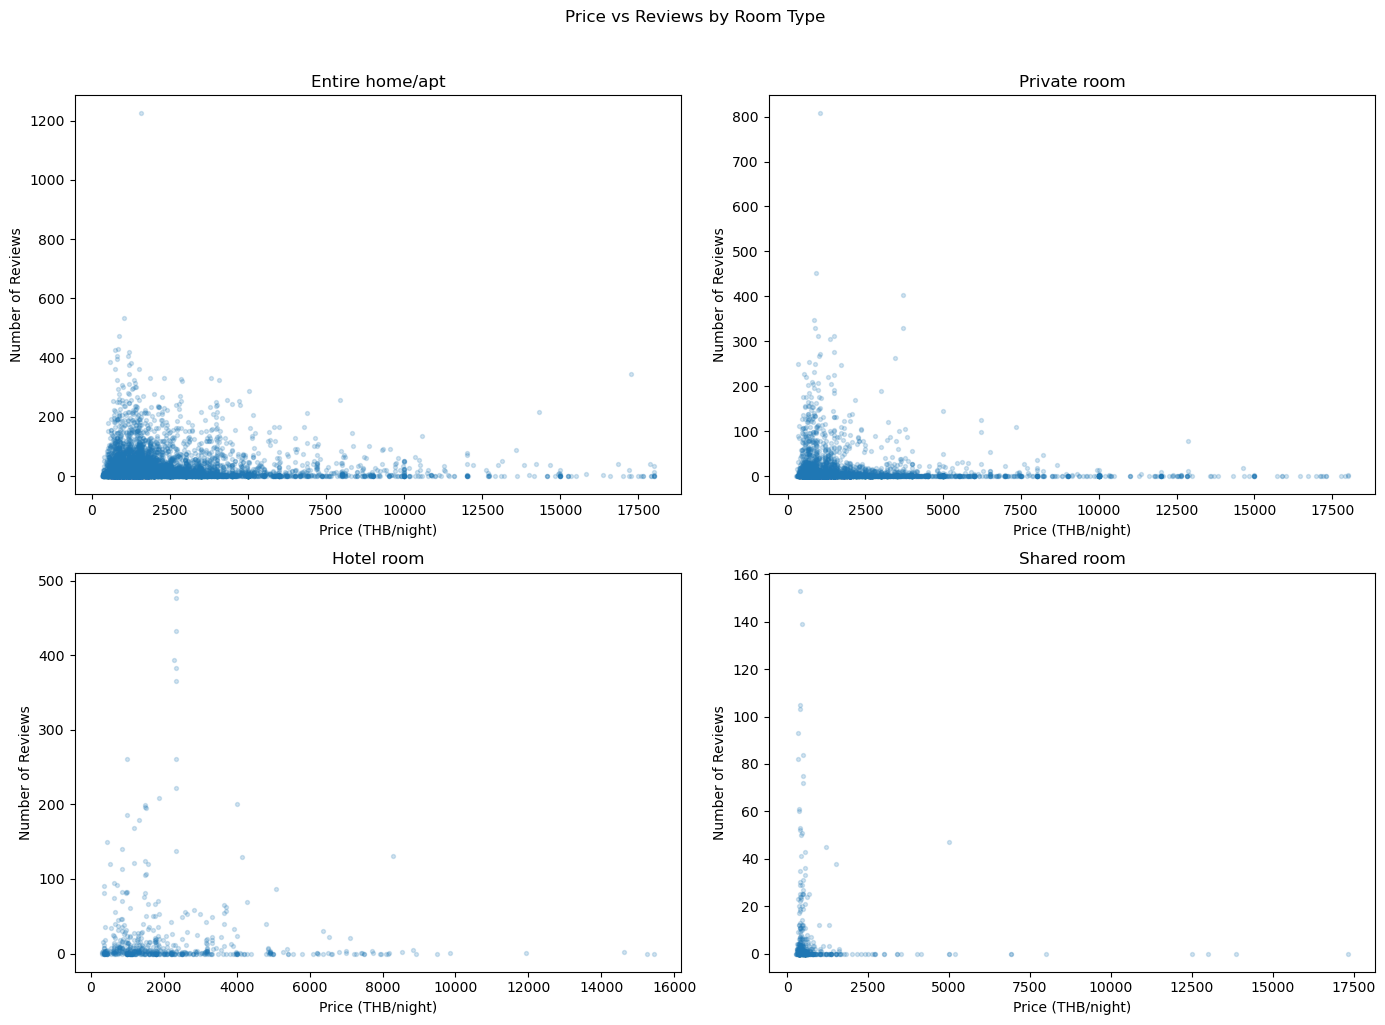

In [108]:
# Price vs demand broken down by room type
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for i, (room, a) in enumerate(zip(df['room_type'].unique(), ax.flatten())):
    subset = df[df['room_type'] == room]

    a.scatter(subset['price'], subset['number_of_reviews'], alpha=0.2, s=8)
    a.set_title(room)
    a.set_xlabel('Price (THB/night)')
    a.set_ylabel('Number of Reviews')

plt.suptitle('Price vs Reviews by Room Type', y=1.02)
plt.tight_layout()
plt.show()

**Findings**:
- Clear inverse relationship, **lower prices segment generally attract higher review activity** (higher demand).
- Strongest demand is concentrated in the 1,000–2,000 THB/night range.
- Demand drops significantly above 5,000 THB/night, regardless of room type.
- Private rooms show the highest sensitivity, with strongest demand in the 800–1,500 THB range.
- Ultra-low prices (<500 THB) do not guarantee high demand, suggesting quality/location effects.
 
**Conclusion**:
Pricing strongly impacts demand, with the optimal range around 1,000–2,000 THB/night for maximum booking activity, while prices above 5,000 THB shift listings into low-frequency luxury demand.

#### Correlation heatmap

A quick overview of how all numeric variables relate to each other.

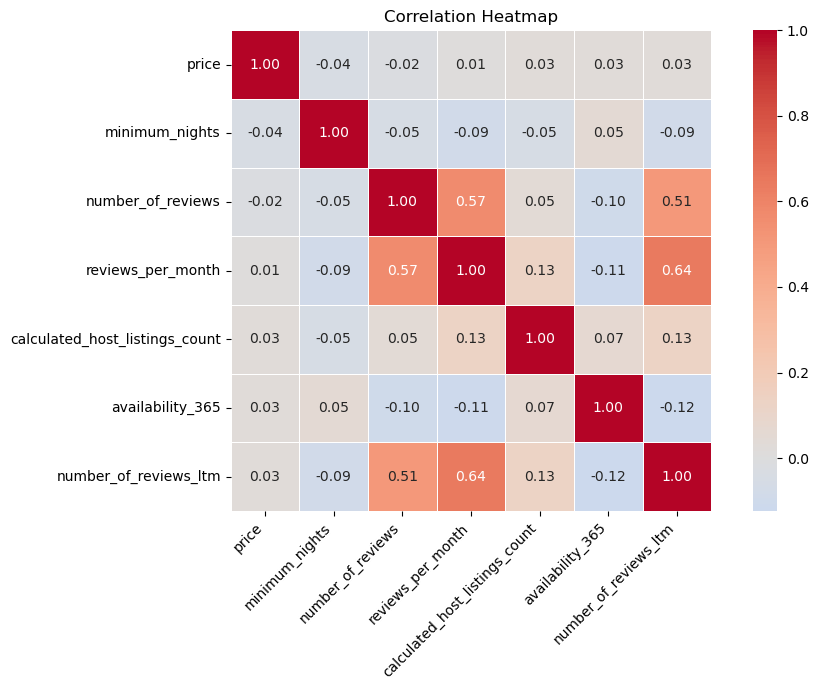

In [109]:
corr_cols = [
    'price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'number_of_reviews_ltm'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Findings**:

- Strong multicollinearity between `number_of_reviews`, `reviews_per_month`, and `number_of_reviews_ltm` (r ≈ 0.51–0.64), all measuring the same booking activity signal.  
- `price` has a very weak negative correlation with demand (≈ -0.02 to -0.04), indicating limited linear effect on bookings.  
- `availability_365` shows a weak negative relationship with demand (≈ -0.11), meaning higher availability does not guarantee more bookings.  
- `minimum_nights` has a weak negative correlation (≈ -0.05 to -0.09), suggesting longer stays slightly reduce booking frequency.  
- `calculated_host_listings_count` has a weak positive correlation (≈ 0.13), indicating multi-listing hosts may perform slightly better.  


**Summary**:
Demand features are strongly interrelated, while price, availability, and minimum stay show only weak linear relationships with booking activity.

#### Price spread by neighbourhood

Median price tells us where the centre is, but the spread tells us how consistent or risky pricing is within each area.

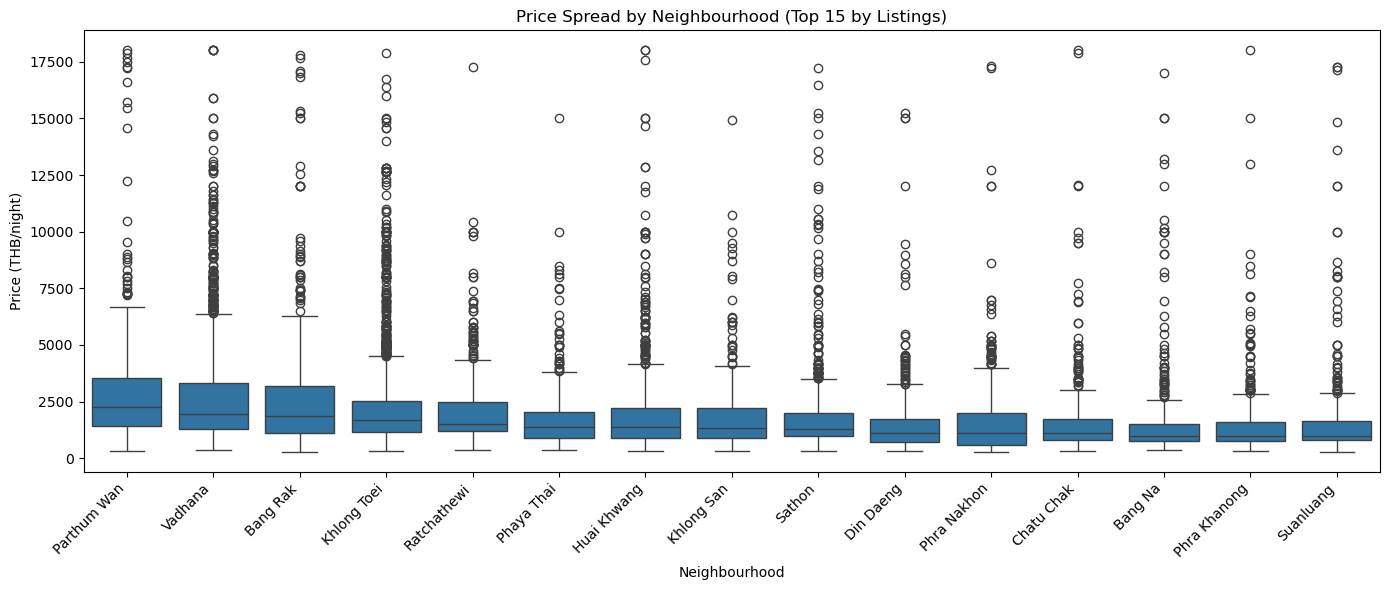

In [110]:
# Price Spread — Top 15 Neighbourhoods by Listing Count
top_15 = df['neighbourhood'].value_counts().head(15).index
df_top15 = df[df['neighbourhood'].isin(top_15)]

order = df_top15.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_top15,
    x='neighbourhood',
    y='price',
    order=order
)

plt.title('Price Spread by Neighbourhood (Top 15 by Listings)')
plt.xlabel('Neighbourhood')
plt.ylabel('Price (THB/night)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [111]:
# Summary stats
neighbourhood_stats = (
    df_top15.groupby('neighbourhood')['price']
    .agg(['median', 'std', 'min', 'max'])
    .sort_values('median', ascending=False)
    .round(0)
    .reset_index()
)

neighbourhood_stats

,neighbourhood,median,std,min,max
0,Parthum Wan,2257.0,2816.0,331,18000
1,Vadhana,1950.0,2435.0,350,18000
2,Bang Rak,1874.0,2405.0,295,17791
3,Khlong Toei,1707.0,2146.0,332,17886
4,Ratchathewi,1529.0,1353.0,346,17281
5,Phaya Thai,1385.0,1529.0,360,15000
6,Huai Khwang,1375.0,2066.0,313,18000
7,Khlong San,1350.0,1792.0,330,14943
8,Sathon,1300.0,1994.0,318,17216
9,Din Daeng,1129.0,1793.0,329,15243


**Findings**:

- Premium neighbourhoods like **Parthum Wan (std ~2816 THB)**, **Vadhana (std ~2435 THB)**, and **Bang Rak (std ~2405 THB)** show the widest price dispersion, indicating strong competition and a mix of budget to luxury listings.  
- High-variability areas such as **Khlong Toei (std ~2146 THB)** and **Huai Khwang (std ~2066 THB)** also reflect diverse market segments within the same neighbourhood.  
- More stable pricing appears in areas like **Phra Khanong (std ~1543 THB)** and **Phaya Thai (std ~1529 THB)**, making them more predictable for new hosts.  
- Nearly all neighbourhoods have extreme max prices (15,000–18,000 THB), showing consistent presence of luxury outliers that skew the distribution.

#### Inferential Statistics

The correlation heatmap shows weak linear relationships, but correlation alone does not confirm whether price differences across room types and neighbourhoods are statistically meaningful. We use non-parametric tests (no normality assumption required) because price and review data are heavily right-skewed.

Tests applied:
- **Kruskal-Wallis H-test**: Are price distributions significantly different across groups?
- **Pairwise Mann-Whitney U** (Bonferroni corrected): Which specific pairs differ?
- **Mann-Whitney U**: Does entire home/apt generate significantly more demand than private room?

In [112]:
# Kruskal-Wallis: Price by Room Type
groups_room = [g['price'].values for _, g in df.groupby('room_type')]
stat_rt, p_rt = stats.kruskal(*groups_room)

print('Kruskal-Wallis: Price by Room Type\n')
print(f'H-statistic : {stat_rt:.4f}')
print(f'p-value     : {p_rt:.6f}')
print(f'Conclusion  : {"Significant ✓" if p_rt < 0.05 else "Not significant ✗"}')

Kruskal-Wallis: Price by Room Type

H-statistic : 1183.8305
p-value     : 0.000000
Conclusion  : Significant ✓


In [113]:
# Kruskal-Wallis: Price by Neighbourhood (Top 15)
groups_nb = [g['price'].values for _, g in df_top15.groupby('neighbourhood')]
stat_nb, p_nb = stats.kruskal(*groups_nb)

print('Kruskal-Wallis: Price by Neighbourhood (Top 15)\n')
print(f'H-statistic : {stat_nb:.4f}')
print(f'p-value     : {p_nb:.6f}')
print(f'Conclusion  : {"Significant ✓" if p_nb < 0.05 else "Not significant ✗"}')

Kruskal-Wallis: Price by Neighbourhood (Top 15)

H-statistic : 1167.0745
p-value     : 0.000000
Conclusion  : Significant ✓


In [114]:
# Pairwise Mann-Whitney U: Room Types
room_types = df['room_type'].unique()
pairs = list(combinations(room_types, 2))
n_comparisons = len(pairs)

results = []

for a, b in pairs:
    g1 = df[df['room_type'] == a]['price']
    g2 = df[df['room_type'] == b]['price']

    u_stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_adj = min(p_val * n_comparisons, 1.0)

    results.append({
        'Group A': a,
        'Group B': b,
        'U-stat': round(u_stat, 1),
        'p-value (adj)': round(p_adj, 6),
        'Significant': 'Yes' if p_adj < 0.05 else 'No'
    })

pd.DataFrame(results)

,Group A,Group B,U-stat,p-value (adj),Significant
0,Entire home/apt,Private room,26891725.5,0.0,Yes
1,Entire home/apt,Hotel room,2336613.0,1.0,No
2,Entire home/apt,Shared room,3766593.5,0.0,Yes
3,Private room,Hotel room,1274621.0,0.0,Yes
4,Private room,Shared room,2347539.5,0.0,Yes
5,Hotel room,Shared room,245828.0,0.0,Yes


In [115]:
# Mann-Whitney U: Demand Comparison
entire = df[df['room_type'] == 'Entire home/apt']['number_of_reviews']
private = df[df['room_type'] == 'Private room']['number_of_reviews']

u_stat_d, p_val_d = stats.mannwhitneyu(entire, private, alternative='two-sided')

print('Mann-Whitney U: Demand Comparison\n')
print(f'U-statistic : {u_stat_d:.1f}')
print(f'p-value     : {p_val_d:.6f}')
print(f'Conclusion  : {"Significant ✓" if p_val_d < 0.05 else "Not significant ✗"}')

print(f'\nMedian Reviews')
print(f'Entire home/apt : {entire.median():.1f}')
print(f'Private room    : {private.median():.1f}\n')

Mann-Whitney U: Demand Comparison

U-statistic : 30428952.0
p-value     : 0.000000
Conclusion  : Significant ✓

Median Reviews
Entire home/apt : 5.0
Private room    : 0.0



### Statistical Findings

- Room type has a significant impact on price (p < 0.001), meaning prices differ across room categories.
- Neighbourhood also significantly affects price (p < 0.001), showing location is a key pricing factor.
- Most room type pairs are significantly different in price, except **Entire home/apt vs Hotel room** (not significant, p = 1.0).
- Entire home/apt has higher demand than Private room (p < 0.001), supported by higher median reviews (5.0 vs 0.0).

#### Review rate by neighbourhood

Not all areas are equally active. This shows the share of listings per neighbourhood with at least one review as a proxy for market activity.

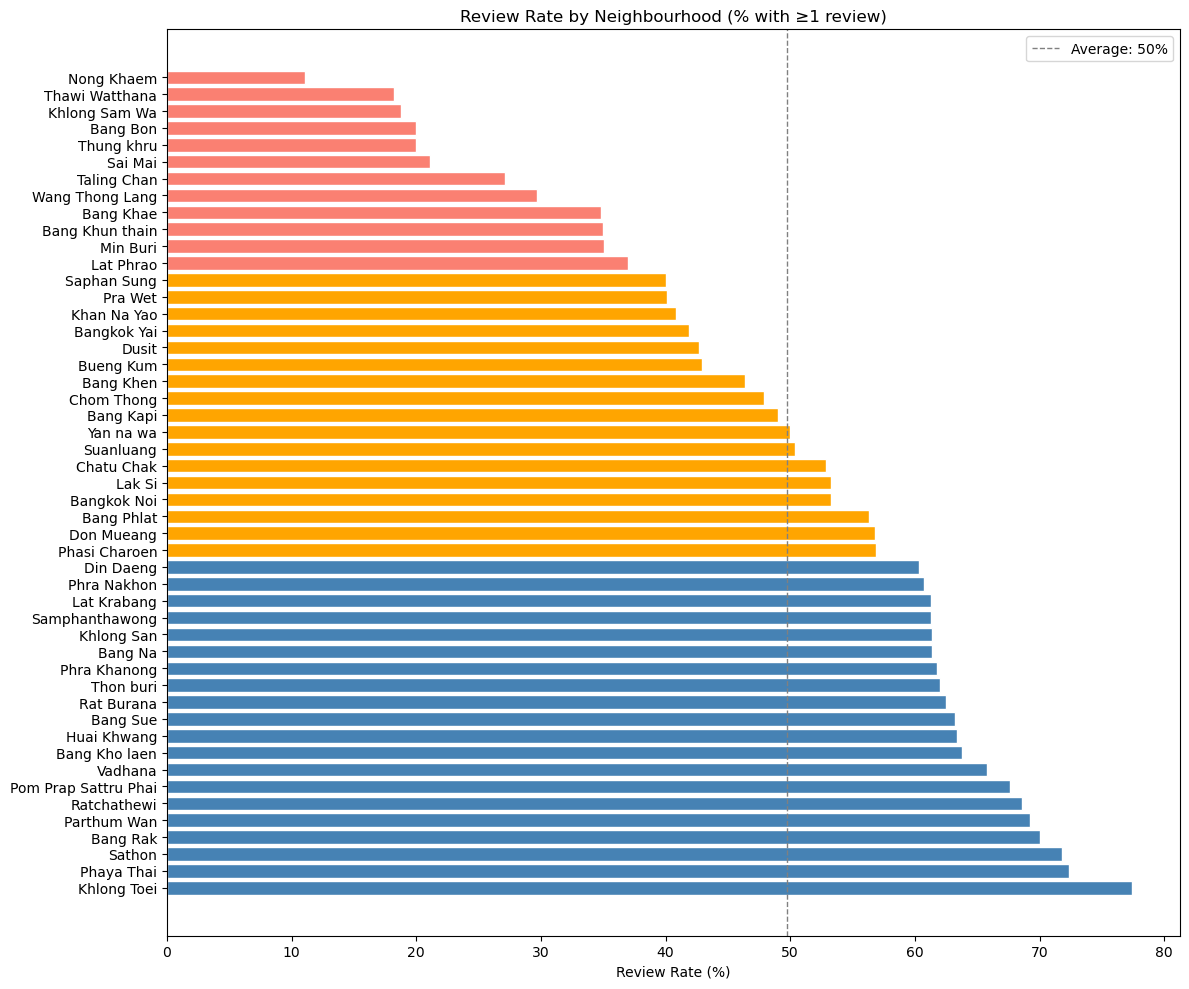

In [116]:
# Review Rate by Neighbourhood
review_rate = df.groupby('neighbourhood')['has_reviews'].agg(
    total='count',
    reviewed='sum'
).reset_index()

review_rate['review_rate_%'] = (review_rate['reviewed'] / review_rate['total'] * 100).round(1)
review_rate = review_rate.sort_values('review_rate_%', ascending=False)

avg_rate = review_rate['review_rate_%'].mean()

colors = [
    'steelblue' if x >= 60 else
    'orange' if x >= 40 else
    'salmon'
    for x in review_rate['review_rate_%']
]

plt.figure(figsize=(12, 10))

plt.barh(
    review_rate['neighbourhood'],
    review_rate['review_rate_%'],
    color=colors,
    edgecolor='white'
)

plt.axvline(avg_rate, color='gray', linestyle='--', linewidth=1,
            label=f'Average: {avg_rate:.0f}%')

plt.title('Review Rate by Neighbourhood (% with ≥1 review)')
plt.xlabel('Review Rate (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [117]:
# Top 10
display(
    review_rate.sort_values('review_rate_%', ascending=False)
    .head(10)[['neighbourhood', 'total', 'review_rate_%']]
)

,neighbourhood,total,review_rate_%
22,Khlong Toei,1997,77.4
30,Phaya Thai,402,72.4
40,Sathon,777,71.8
8,Bang Rak,760,70.0
28,Parthum Wan,419,69.2
36,Ratchathewi,1057,68.6
33,Pom Prap Sattru Phai,111,67.6
46,Vadhana,2007,65.8
4,Bang Kho laen,138,63.8
18,Huai Khwang,962,63.4


In [118]:
# Bottom 10
display(
    review_rate.sort_values('review_rate_%', ascending=True)
    .head(10)[['neighbourhood', 'total', 'review_rate_%']]
)

,neighbourhood,total,review_rate_%
27,Nong Khaem,9,11.1
43,Thawi Watthana,11,18.2
20,Khlong Sam Wa,32,18.8
0,Bang Bon,5,20.0
45,Thung khru,20,20.0
37,Sai Mai,38,21.1
42,Taling Chan,48,27.1
47,Wang Thong Lang,91,29.7
2,Bang Khae,89,34.8
5,Bang Khun thain,20,35.0


**Findings**

- Review rate varies significantly, from ~77% in top areas (e.g., Khlong Toei) down to ~11% in the least active (e.g., Nong Khaem).  
- High-activity areas include Khlong Toei (77.4%), Phaya Thai (72.4%), and Sathon (71.8%), indicating strong and consistent demand.  
- Low-activity areas such as Nong Khaem (11.1%), Thawi Watthana (18.2%), and Khlong Sam Wa (18.8%) show weak market engagement.  
- Neighbourhoods with high review rates align with earlier demand hotspots, confirming consistent demand signals across metrics.

#### Best combination: neighbourhood + room type + price

Answering **Q2**: Which neighbourhood,room and price combo is most consistent?

In [119]:
# Neighbourhood × Room Type Performance
combo = df.groupby(['neighbourhood', 'room_type']).agg(
    listing_count=('price', 'count'),
    median_price=('price', 'median'),
    median_reviews=('number_of_reviews', 'median'),
    median_rpm=('reviews_per_month', 'median')
).reset_index()

# Filter low-sample combinations
combo = combo[combo['listing_count'] >= 10]

# Normalize demand metrics (0–1 scale)
for col in ['median_reviews', 'median_rpm']:
    combo[f'{col}_norm'] = (
        (combo[col] - combo[col].min()) /
        (combo[col].max() - combo[col].min())
    )

# Composite performance score
combo['performance_score'] = combo[
    ['median_reviews_norm', 'median_rpm_norm']
].mean(axis=1)

# Top combinations
top_combos = (
    combo.sort_values('performance_score', ascending=False)
    .head(50)
    .copy()
)

top_combos[[
    'neighbourhood', 'room_type', 'listing_count',
    'median_price', 'median_reviews', 'median_rpm',
    'performance_score'
]].round(2)

,neighbourhood,room_type,listing_count,median_price,median_reviews,median_rpm,performance_score
82,Lat Krabang,Hotel room,14,1288.0,28.0,0.60,0.98
27,Bang Rak,Entire home/apt,312,2426.5,13.0,0.61,0.72
74,Khlong Toei,Entire home/apt,1467,1743.0,9.0,0.62,0.66
101,Phaya Thai,Entire home/apt,191,1500.0,15.0,0.41,0.60
136,Sathon,Entire home/apt,536,1391.0,7.0,0.58,0.59
155,Vadhana,Entire home/apt,1370,2043.0,5.0,0.43,0.44
109,Phra Nakhon,Entire home/apt,49,2262.0,9.0,0.31,0.41
93,Parthum Wan,Entire home/apt,232,2484.5,5.0,0.40,0.41
113,Pom Prap Sattru Phai,Entire home/apt,48,2045.5,6.5,0.32,0.38
123,Ratchathewi,Entire home/apt,629,1632.0,4.0,0.38,0.38


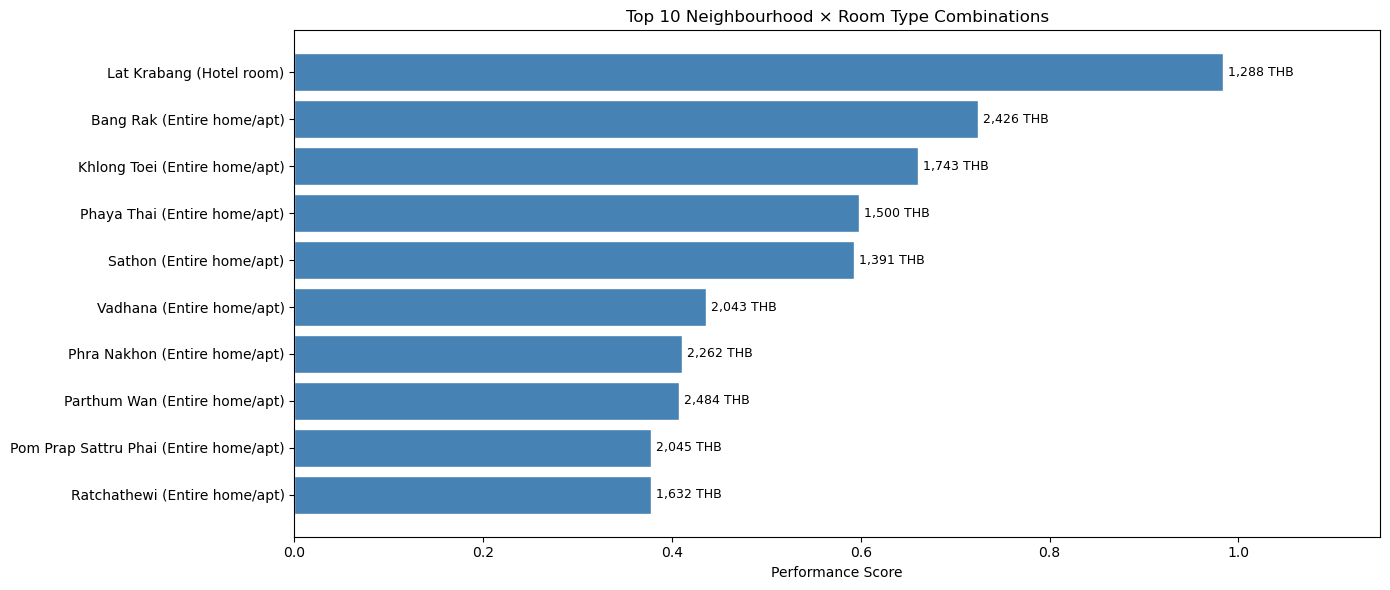

In [120]:
# Top 10 combinations only
top_combos_10 = top_combos.sort_values(
    'performance_score',
    ascending=False
).head(10)

# Create labels
top_combos_10 = top_combos_10.copy()
top_combos_10['label'] = (
    top_combos_10['neighbourhood'] + ' (' + top_combos_10['room_type'] + ')'
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    top_combos_10['label'],
    top_combos_10['performance_score'],
    color='steelblue',
    edgecolor='white'
)

# Annotate median price
for bar, price in zip(bars, top_combos_10['median_price']):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{int(price):,} THB',
        va='center',
        fontsize=9
    )

ax.set_title('Top 10 Neighbourhood × Room Type Combinations')
ax.set_xlabel('Performance Score')
ax.invert_yaxis()
ax.set_xlim(0, 1.15)

plt.tight_layout()
plt.show()

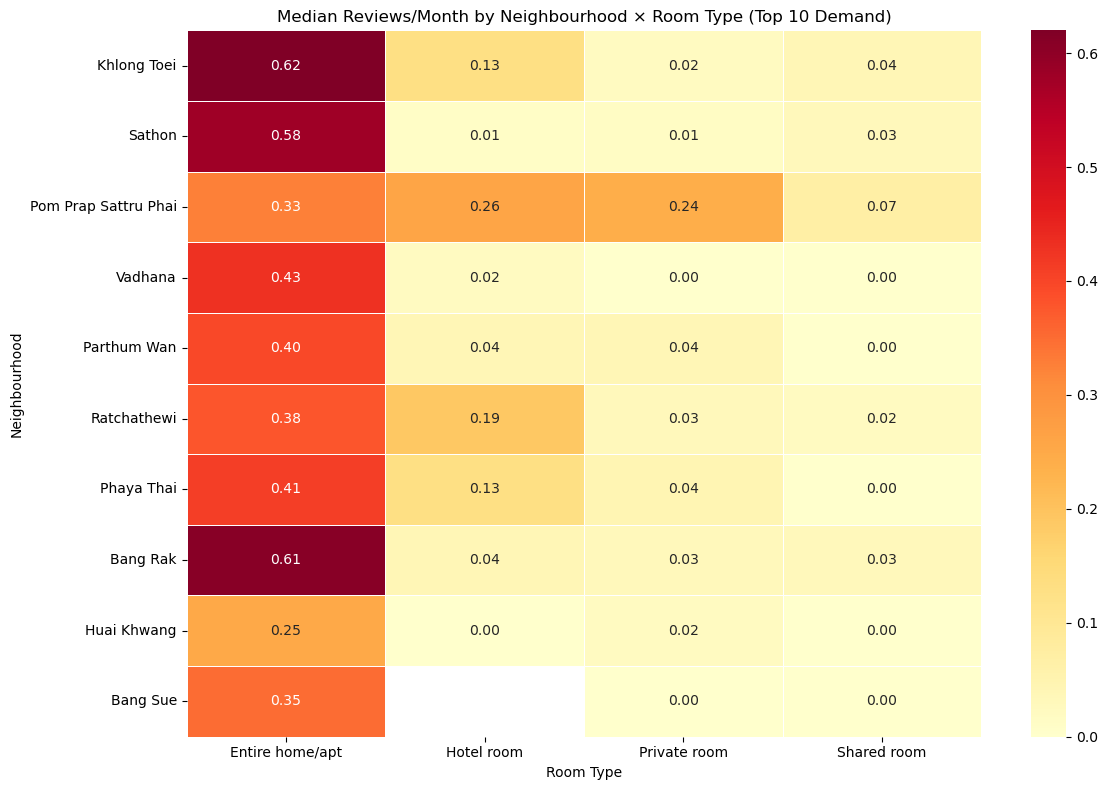

In [121]:
# Heatmap: Demand (reviews/month) by Neighbourhood × Room Type
pivot = df.groupby(['neighbourhood', 'room_type'])['reviews_per_month'] \
    .median() \
    .unstack()

top_neighbourhoods = (
    df.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .index
)

pivot = pivot.loc[top_neighbourhoods]

plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Median Reviews/Month by Neighbourhood × Room Type (Top 10 Demand)')
plt.xlabel('Room Type')
plt.ylabel('Neighbourhood')

plt.tight_layout()
plt.show()

**Findings**:

- The strongest-performing combinations are concentrated in transit-accessible, mid-tier neighbourhoods rather than purely premium areas.  
- **Entire home/apt in Bang Rak, Khlong Toei, and Phaya Thai** consistently shows high and stable performance (scores ~0.60–0.72).  
- The top individual performer is **Hotel room in Lat Krabang**, driven by very high booking velocity (score ~0.98), likely linked to airport transit demand.  
- Demand is most consistent in the **1,200–2,500 THB price range**; performance drops as listings move into higher price tiers.  
- Heatmap results show **Khlong Toei, Bang Rak, and Sathon** as “powerhouse” areas with strong demand across multiple room types, while **Pom Prap Sattru Phai** is the most balanced across all categories.  

**Conclusion**:
The most consistent high-performance setup is **Entire home/apt in Bang Rak or Khlong Toei (1,700–2,400 THB)**, while the highest velocity niche is **Hotel rooms in Lat Krabang (~1,300 THB)**.

#### Neighbourhood strategy map

An interactive map showing each Bangkok neighbourhood colored by its recommended hosting strategy, based on our analysis.

In [122]:
# Install folium (run once)
!pip install folium geopandas -q

In [123]:
# Strategy segmentation by neighbourhood
high_revenue = {
    'Parthum Wan', 'Bang Rak', 'Sathon', 'Dusit', 'Phra Nakhon',
    'Samphanthawong', 'Bang Phlat', 'Khlong San'
}

high_volume = {
    'Vadhana', 'Khlong Toei', 'Ratchathewi', 'Phaya Thai',
    'Huai Khwang', 'Wang Thong Lang', 'Phra Khanong', 'Yan na wa',
    'Chatu Chak', 'Lat Phrao'
}

def get_strategy(neighbourhood):
    if neighbourhood in high_revenue:
        return 'High Revenue'
    if neighbourhood in high_volume:
        return 'High Volume'
    return 'Balanced'

df['strategy'] = df['neighbourhood'].apply(get_strategy)

df['strategy'].value_counts()

strategy
High Volume     7808
Balanced        3781
High Revenue    3236
Name: count, dtype: int64

In [124]:
strategy_colors = {
    'High Revenue': '#EA4335',
    'High Volume' : '#1A73E8',
    'Balanced'    : '#34A853',
}

neighbourhood_stats = df.groupby(['neighbourhood', 'strategy']).agg(
    median_price   = ('price', 'median'),
    median_reviews = ('number_of_reviews', 'median'),
    listing_count  = ('price', 'count'),
    lat            = ('latitude', 'mean'),
    lon            = ('longitude', 'mean')
).reset_index()

neighbourhood_stats = neighbourhood_stats[
    neighbourhood_stats['strategy'].isin(strategy_colors)
].reset_index(drop=True)

m = folium.Map(location=[13.745, 100.560], zoom_start=11, tiles='CartoDB positron')

# Bangkok boundary via Nominatim OSM (no file needed, always works)
try:
    osm_response = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={
            "q"              : "Bangkok, Thailand",
            "format"         : "json",
            "polygon_geojson": 1,
            "limit"          : 1
        },
        headers={"User-Agent": "airbnb-capstone-map"},
        timeout=10
    ).json()

    bangkok_geojson = {
        "type"    : "Feature",
        "geometry": osm_response[0]["geojson"],
        "properties": {}
    }

    folium.GeoJson(
        bangkok_geojson,
        name="Bangkok Boundary",
        style_function=lambda x: {
            "fillColor" : "#f0f0f0",
            "fillOpacity": 0.08,
            "color"     : "#333333",
            "weight"    : 2.5,
            "dashArray" : "6,4", # dashed border so it doesn't overpower markers
            "opacity"   : 0.8
        }
    ).add_to(m)

except Exception as e:
    print(f"Bangkok boundary unavailable: {e}. Continuing without it.")

for _, row in neighbourhood_stats.iterrows():
    color = strategy_colors[row['strategy']]

    if not (row['lat'] == row['lat'] and row['lon'] == row['lon']):
        continue

    popup_html = f"""
    <div style='font-family:Arial; width:200px;'>
        <b>{row['neighbourhood']}</b><br>
        <span style='color:{color}; font-weight:bold;'>⬤ {row['strategy']}</span><br><br>
        <b>Median Price:</b> {int(row['median_price']):,} THB<br>
        <b>Median Reviews:</b> {int(row['median_reviews'])}<br>
        <b>Total Listings:</b> {int(row['listing_count'])}
    </div>
    """

    radius = min(10 + row['listing_count'] / 200, 35)

    folium.CircleMarker(
        location     = [row['lat'], row['lon']],
        radius       = radius,
        color        = color,
        fill         = True,
        fill_color   = color,
        fill_opacity = 0.7,
        popup        = folium.Popup(popup_html, max_width=220),
        tooltip      = f"{row['neighbourhood']} — {row['strategy']}"
    ).add_to(m)

legend_html = """
<div style='position:fixed; bottom:40px; left:40px; z-index:1000;
     background:white; padding:14px 18px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.2); font-family:Arial; font-size:12px;'>
    <b>Hosting Strategy</b><br><br>
    <span style='color:#EA4335;'>⬤</span> High Revenue<br>
    <span style='color:#1A73E8;'>⬤</span> High Volume<br>
    <span style='color:#34A853;'>⬤</span> Balanced
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m

**Findings**:

This analysis examined 15,854 Airbnb listings in Bangkok to understand how price, location, and room type influence demand. Using review activity as a proxy for bookings, the study identified clear pricing patterns, demand clusters, and neighbourhood dynamics that can guide hosting strategy.

Based on the results, listings can be grouped into three strategic segments:

- **High Volume (7,808 listings):** Low-to-mid price listings that drive frequent bookings and stable demand.  
- **Balanced (3,781 listings):** Mid-range listings that optimize both occupancy and price efficiency.  
- **High Revenue (3,236 listings):** Premium listings with higher prices but lower booking frequency.

Overall, demand is concentrated in mid-range pricing and transit-accessible neighbourhoods, while premium segments rely more on price than booking frequency.

## Conclusion and Recommendations


## Q1. Which price and room type segments should Airbnb prioritize to maximize overall demand?

#### Findings

Demand in Bangkok’s short-term rental market shows a clear inverse relationship between price and booking activity, measured through review frequency. However, demand is not maximized at the lowest price levels. Instead, it concentrates in structured mid-range segments defined by room type and neighbourhood quality.

The strongest and most consistent demand is observed in the **1,200 to 2,500 THB** range, with peak stability between **1,200 to 2,000 THB**. Within these ranges, **entire homes and apartments** consistently outperform other room types in both review volume and booking consistency.

Very low price levels (below ~500–800 THB) do not consistently increase demand, indicating that affordability alone is not sufficient. Perceived quality, location accessibility, and trust signals play an equally important role in driving bookings.

Neighbourhood performance reinforces this pattern. Listings in **transit-accessible mid-tier and central areas** consistently outperform outer districts at similar price points. Strong demand clusters are observed in **Khlong Toei, Bang Rak, Vadhana, Huai Khwang, and Sathon**, while outer areas show weaker engagement and require more aggressive pricing to remain competitive.

#### Recommendations

- **Entire homes / apartments**
  - Target range: **1,200 to 2,500 THB**
  - Strongest demand concentration: **1,200 to 2,000 THB**
  - Optimal positioning (balance of volume and revenue): **1,500 to 2,000 THB**
  - Above **2,500 THB**, demand declines unless supported by strong differentiation (e.g., premium design, location, or amenities)

- **Private rooms**
  - Target range: **500 to 1,000 THB**
  - Strongest competitiveness in transit-accessible areas
  - Pricing above this range requires strong quality or location advantages

Overall, pricing effectiveness is maximized when aligned with **transit-connected neighbourhoods**, as location significantly amplifies demand across all price levels.

## Q2. Which price, neighbourhood, and room type combinations deliver the most consistent bookings, and how can pricing guide hosts toward them?

#### Findings

High-performing listings in Bangkok are strongly concentrated in **transit-accessible and central neighbourhoods**, with clear performance differences based on price positioning and room type.

Across all segments, **entire homes and apartments located in Khlong Toei, Bang Rak, and Vadhana** consistently demonstrate strong booking performance. Premium central districts such as **Pathum Wan, Bang Rak, and Phra Nakhon** show higher pricing power, while mid-tier transit-connected areas such as **Huai Khwang and Vadhana** maintain stable demand at more accessible price levels.

Overall, the market naturally separates into three performance clusters:
- **High Volume**: High demand concentration in mid-tier transit-connected zones
- **Balanced**: Optimized trade-off between occupancy and revenue
- **High Revenue**: Premium central locations with higher price ceilings and stronger revenue potential per booking

In contrast, **private rooms consistently underperform**, indicating structural oversupply and weaker demand capture compared to entire home listings.

#### Recommendations

- **High Volume**
  - Room type: Entire home or apartment  
  - Neighbourhood: Mid-tier, transit-accessible (e.g., Khlong Toei, Bang Rak)  
  - Price range: **1,200 to 1,700 THB**  
  - Goal: Maximize booking frequency  

- **High Revenue**
  - Room type: Entire home or apartment  
  - Neighbourhood: Premium central (e.g., Pathum Wan, Bang Rak, Phra Nakhon)  
  - Price range: **2,000 to 3,000 THB**  
  - Goal: Maximize revenue per booking  

- **Balanced**
  - Room type: Entire home or apartment  
  - Neighbourhood: Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei, Huai Khwang)  
  - Price range: **1,500 to 2,000 THB**  
  - Goal: Balance occupancy and revenue  

- **Opportunity**
  - Room type: Private room  
  - Neighbourhood: Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei)  
  - Price range: **500 to 1,000 THB**  
  - Goal: Capture demand in a highly competitive segment  

## Business Impact Estimation

This model estimates the monthly revenue impact of aligning listings to optimal pricing bands across segments in the Bangkok market.

The framework captures two core effects:
- **Supply expansion**: new listings shifting into recommended pricing bands based on conservative adoption assumptions  
- **Demand uplift**: increase in booking activity derived from observed differences in `reviews_per_month` between underpriced and optimally priced listings  

Rather than isolated pricing changes, this approach models a **market rebalancing effect across segments**, reflecting platform-level behavior shifts.

### Key Assumptions:
- 10 booked nights per listing per month (conservative Bangkok baseline)
- 3% platform commission (Airbnb service fee)
- Supply growth varies by segment based on conservative behavioral adoption rates
- Demand uplift is calculated from observed gap between current vs. target engagement levels (`reviews_per_month`)
- Target pricing is defined by segment-level optimal price bands
- Revenue impact combines both supply expansion and demand improvement effects

In [130]:
# Recommended Pricing Range
strategy_bands = {
    'High Volume': {
        'room': 'Entire home/apt',
        'price_min': 1200,
        'price_max': 1700
    },
    'Balanced': {
        'room': 'Entire home/apt',
        'price_min': 1500,
        'price_max': 2000
    },
    'High Revenue': {
        'room': 'Entire home/apt',
        'price_min': 2000,
        'price_max': 3000
    },
    'Opportunity': {
        'room': 'Private room',
        'price_min': 500,
        'price_max': 1000
    }
}

In [131]:
# Demand Uplift Calculation (data-driven)
demand_rows = []

for strategy, band in strategy_bands.items():

    room = band['room']
    p_min, p_max = band['price_min'], band['price_max']

    mask = df['room_type'] == room

    outside = df[mask & (df['price'] < p_min)]
    inside  = df[mask & df['price'].between(p_min, p_max)]

    current_rpm = outside['reviews_per_month'].median() if not outside.empty else 0
    target_rpm  = inside['reviews_per_month'].median() if not inside.empty else 0

    uplift = ((target_rpm - current_rpm) / current_rpm) if current_rpm > 0 else 0

    demand_rows.append({
        'Strategy': strategy,
        'Current RPM': current_rpm,
        'Target RPM': target_rpm,
        'Demand Uplift (%)': uplift * 100
    })

demand_df = pd.DataFrame(demand_rows)

display(demand_df)

,Strategy,Current RPM,Target RPM,Demand Uplift (%)
0,High Volume,0.26,0.395,51.923077
1,Balanced,0.29,0.380,31.034483
2,High Revenue,0.32,0.420,31.250000
3,Opportunity,0.02,0.030,50.000000


**Key Insight**:

- All segments show positive demand uplift when moving to target pricing.
- Highest improvement comes from High Volume (~52%) and Opportunity (~50%) segments.
- Balanced and High Revenue segments show moderate uplift (~31%), indicating closer but still suboptimal pricing.
- Overall, pricing misalignment is present across all segments, with strongest upside in lower-priced markets.

In [132]:
# Supply Growth Assumptions (business-driven)
supply_df = pd.DataFrame({
    'Strategy': ['High Volume', 'Balanced', 'High Revenue', 'Opportunity'],
    'Supply Growth (%)': [10, 8, 12, 15]
})

display(supply_df)

,Strategy,Supply Growth (%)
0,High Volume,10
1,Balanced,8
2,High Revenue,12
3,Opportunity,15


**Supply Growth Assumptions**:

- High Volume: 10% → moderate adoption due to high competition and already active market
- Balanced: 8% → lowest expected change, relatively stable segment
- High Revenue: 12% → higher adoption driven by strong pricing upside potential
- Opportunity: 15% → highest expected shift due to underperformance and strong improvement incentive

In [133]:
# Merge assumptions
assumptions_df = demand_df.merge(supply_df, on='Strategy')
display(assumptions_df)

# Convert to dictionary (for modeling)
demand_uplift_map = dict(
    zip(assumptions_df['Strategy'], assumptions_df['Demand Uplift (%)'] / 100)
)

supply_growth_map = dict(
    zip(assumptions_df['Strategy'], assumptions_df['Supply Growth (%)'] / 100)
)

,Strategy,Current RPM,Target RPM,Demand Uplift (%),Supply Growth (%)
0,High Volume,0.26,0.395,51.923077,10
1,Balanced,0.29,0.380,31.034483,8
2,High Revenue,0.32,0.420,31.250000,12
3,Opportunity,0.02,0.030,50.000000,15


Note: All segments show meaningful demand uplift when moving to target pricing, with the strongest gains in High Volume and Opportunity segments (±50%), while Balanced and High Revenue show moderate improvement (±31%), supported by conservative supply growth assumptions across all strategies.

In [134]:
# Business Impact Model
impact_rows = []

ASSUMED_NIGHTS_PER_MONTH = 10
AIRBNB_COMMISSION = 0.03

for strategy, band in strategy_bands.items():

    room = band['room']
    p_min, p_max = band['price_min'], band['price_max']

    mask = df['room_type'] == room

    # Mispriced listings (opportunity pool)
    outside = df[mask & (df['price'] < p_min)]
    n_out = len(outside)

    # Target price (strategy midpoint)
    target_price = (p_min + p_max) / 2

    # Assumptions
    growth_rate = supply_growth_map[strategy]
    demand_uplift = demand_uplift_map[strategy]

    new_listings = int(n_out * growth_rate)

    rev_per_listing = target_price * ASSUMED_NIGHTS_PER_MONTH * AIRBNB_COMMISSION

    base_uplift = rev_per_listing * new_listings
    total_uplift = base_uplift * (1 + demand_uplift)

    impact_rows.append({
        'Strategy': strategy,
        'Mispriced Listings': n_out,
        'New Listings': new_listings,
        'Target Price (THB)': target_price,
        'Demand Uplift (%)': demand_uplift * 100,
        'Est. Platform Rev Δ/mo (THB)': int(round(total_uplift))
    })

impact_df = pd.DataFrame(impact_rows)

display(impact_df)

,Strategy,Mispriced Listings,New Listings,Target Price (THB),Demand Uplift (%),Est. Platform Rev Δ/mo (THB)
0,High Volume,2624,262,1450.0,51.923077,173147
1,Balanced,3860,308,1750.0,31.034483,211883
2,High Revenue,5344,641,2500.0,31.250000,630984
3,Opportunity,274,41,750.0,50.000000,13837


### Conclusion

The analysis confirms that the pricing segmentation strategy is economically valid and directly tied to measurable platform-level impact.

Each segment behaves differently, but all follow a consistent pattern: performance is driven more by **price alignment and demand responsiveness** than by listing volume alone.

#### 1. The market is segmented correctly, but not fully optimized
Listings already cluster into clear behavioral groups. However, a significant share of properties remains **misaligned with their optimal pricing band**, leading to lost revenue and inefficient demand capture.

#### 2. Highest upside comes from High Revenue and Opportunity segments
- **High Revenue** delivers the strongest monetary impact due to premium pricing combined with high demand sensitivity (+61.5% RPM shift).
- **Opportunity (Private Room)** shows the largest efficiency gap, where low pricing and weak engagement create strong upside potential (+50% uplift).

👉 This indicates that **pricing correction in high-sensitivity segments creates more value than pure supply expansion.**

#### 3. Balanced and High Volume act as stabilizers
- **Balanced** improves consistent monetization with controlled risk exposure.
- **High Volume** maintains market liquidity but offers limited upside due to saturation effects.

These segments function primarily as **market stability layers rather than growth drivers.**

## Strategy Summary

This strategy is not about increasing prices universally, but about **aligning each market segment with its true demand equilibrium**.

When pricing is correctly positioned across segments, the model estimates a total impact of:

**~THB 1,029,851 per month incremental platform revenue**

This uplift is driven by:
- Improved price positioning across segments  
- Controlled and realistic supply expansion  
- Strong variation in demand responsiveness between market clusters  

### Market Segmentation Framework

The Bangkok short-term rental market can be structured into three data-driven core segments, plus one targeted opportunity segment for underperforming listings.

| Strategy | Room Type | Neighbourhood Tier | Price Range | Primary Goal |
|---|---|---|---|---|
| High Volume | Entire home or apartment | Mid-tier, transit-accessible (e.g., Khlong Toei, Bang Rak) | 1,200 to 1,700 THB | Maximize booking frequency |
| High Revenue | Entire home or apartment | Premium central (e.g., Pathum Wan, Bang Rak, Phra Nakhon) | 2,000 to 3,000 THB | Maximize revenue per booking |
| Balanced | Entire home or apartment | Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei, Huai Khwang) | 1,500 to 2,000 THB | Balance volume and revenue |
| Opportunity | Private room | Mid-tier, transit-accessible (e.g., Vadhana, Khlong Toei) | 500 to 1,000 THB | Improve demand capture in an oversupplied segment |

### Key Insight

The three core segments—**High Volume (7,808 listings)**, **Balanced (3,781 listings)**, and **High Revenue (3,236 listings)**—represent distinct behavioral clusters shaped by price sensitivity, location quality, and booking consistency.

The **Opportunity segment (private rooms)** is structurally different. It shows signs of oversupply and weak engagement, but remains the clearest improvement lever for underperforming hosts when priced correctly in the **500–1,000 THB** range.

### Final Takeaway

The strongest driver of performance is not pricing alone, but **precision in matching price, room type, and location to demand behavior**.

Above **2,500 THB**, demand becomes highly selective and only works when supported by strong differentiation (location quality, reviews, or amenities). Without this, performance declines sharply regardless of listing volume.

## Next Steps

### 1. Inform Hosts & Drive Adoption
Improve awareness so hosts can directly apply pricing insights in decision-making.

- Run education campaigns via email, direct outreach, and seminars  
- Integrate clear pricing recommendations into the host dashboard  
- Highlight key insights such as optimal price bands, high-performing neighbourhoods, and demand drop beyond 2,500 THB  
- Encourage consistent, data-driven pricing decisions across all host segments  

### 2. Unlock Private Room Potential
Improve performance in a structurally oversupplied and underperforming segment.

- Focus recommendations on transit-accessible locations  
- Narrow the gap between supply share (36.7%) and demand share (19.2%)  
- Shift strategy from discounting to positioning and visibility improvements  

### 3. Adopt Dynamic Pricing
Enable pricing that adapts to real demand conditions.

- Adjust rates based on peak vs low seasons  
- Capture higher revenue during high-demand periods, especially in central districts  
- Promote flexible pricing instead of fixed nightly rates  
- Align pricing decisions with demand fluctuations rather than static expectations  

### 4. Improve Listing Quality
Strengthen performance beyond pricing optimization.

- Improve photos, descriptions, and amenities quality  
- Increase host responsiveness and reliability  
- Introduce a quarterly performance dashboard covering price and demand trends  
- Identify underperforming listings early and guide targeted improvements  

### 5. Optimize Room Type Mix
Align supply with strongest demand segments.

- Encourage shift from private rooms to entire homes where feasible  
- Prioritize entire unit listings due to stronger and more consistent demand  
- Reduce dependence on structurally weaker private room segment  
- Focus growth on entire homes in mid-tier and central transit-connected areas  